In [1]:
import os
print(os.getcwd())
print(os.listdir("."))

c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook
['.ipynb_checkpoints', '01_data_exploration.ipynb', 'day3_preprocessed.csv', 'day4_top_words_per_class.png', 'day4_verified.csv', 'eda_bigrams.png', 'eda_rare_words.png', 'eda_token_distribution.png', 'eda_trigrams.png', 'eda_wordcloud_all.png', 'eda_wordcloud_per_class.png', 'financial_news.csv', 'Untitled.ipynb', 'Week2_Modeling.ipynb']


In [10]:
import os
import pandas as pd


print(f"Working directory: {os.getcwd()}")


if "day4_verified.csv" in os.listdir("."):
    print("day4_verified.csv found ")
else:
    print("day4_verified.csv NOT found  — check your folder")

df = pd.read_csv("day4_verified.csv")
df["label"] = df["label"].astype(int)

print(f"\nDataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Working directory: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook
day4_verified.csv found 

Dataset loaded successfully
Shape: (9380, 6)
Columns: ['text', 'label', 'word_count', 'cleaned_text', 'tokens', 'token_count']


,text,label,word_count,cleaned_text,tokens,token_count
0,$BYND - JPMorgan reels in expectations on Beyo...,0,10,$BYND - jpmorgan reels in expectations on beyo...,"['$BYND', '-', 'jpmorgan', 'reels', 'in', 'exp...",9
1,$CCL $RCL - Nomura points to bookings weakness...,0,14,$CCL $RCL - nomura points to bookings weakness...,"['$CCL', '$RCL', '-', 'nomura', 'points', 'to'...",13
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0,14,"$CX - cemex cut at credit suisse, j.p. morgan ...","['$CX', '-', 'cemex', 'cut', 'at', 'credit', '...",13


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

print("All imports successful")
print(f"Working directory: {os.getcwd()}")

All imports successful
Working directory: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook


In [4]:
df = pd.read_csv("day4_verified.csv")
df["label"] = df["label"].astype(int)

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
for lbl, count in df["label"].value_counts().sort_index().items():
    pct = count / len(df) * 100
    print(f"  {LABEL_MAP[lbl]}: {count} ({pct:.1f}%)")

Dataset loaded successfully
Shape: (9380, 6)
Columns: ['text', 'label', 'word_count', 'cleaned_text', 'tokens', 'token_count']

Label distribution:
  Bearish: 1428 (15.2%)
  Bullish: 1904 (20.3%)
  Neutral: 6048 (64.5%)


In [5]:
from sklearn.model_selection import train_test_split
train_df,temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)
val_df,test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)
print(f"Train size:      {len(train_df)} rows")
print(f"Validation size: {len(val_df)} rows")
print(f"Test size:       {len(test_df)} rows")
print(f"Total:           {len(train_df) + len(val_df) + len(test_df)} rows")

Train size:      7504 rows
Validation size: 938 rows
Test size:       938 rows
Total:           9380 rows


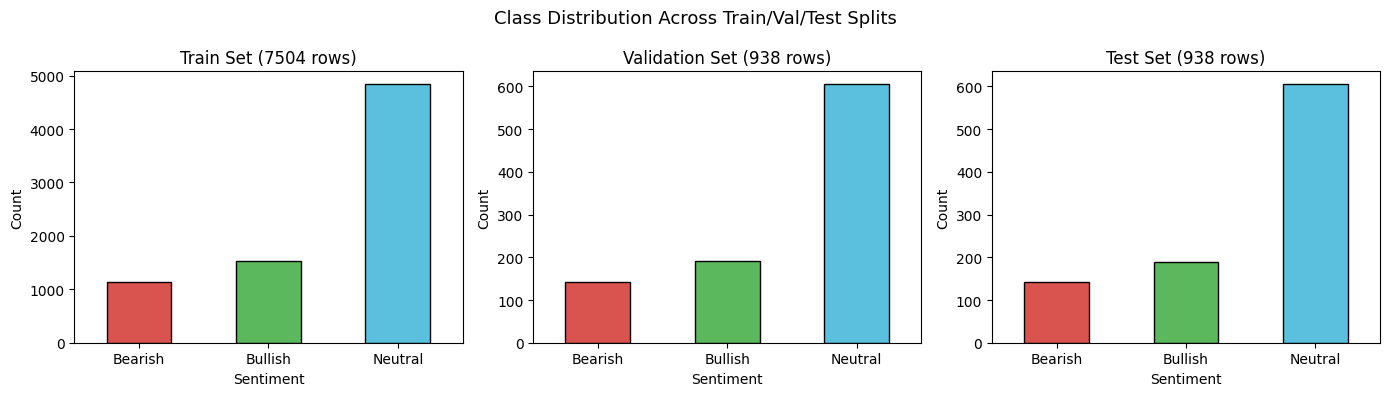

Saved: week2_split_distribution.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#d9534f", "#5cb85c", "#5bc0de"]
splits = [("Train", train_df), ("Validation", val_df), ("Test", test_df)]

for i, (name, split) in enumerate(splits):
    counts = split["label"].value_counts().sort_index()
    counts.rename(index=LABEL_MAP).plot(
        kind="bar",
        ax=axes[i],
        color=colors,
        edgecolor="black"
    )
    axes[i].set_title(f"{name} Set ({len(split)} rows)")
    axes[i].set_xlabel("Sentiment")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Class Distribution Across Train/Val/Test Splits", fontsize=13)
plt.tight_layout()
plt.savefig("week2_split_distribution.png")
plt.show()
print("Saved: week2_split_distribution.png")

In [7]:
# lock away test set immediately
# never touch it until final model evaluation in Day 5
test_df.to_csv("test_set.csv", index=False)

print(f"Test set locked and saved: test_set.csv")
print(f"Shape: {test_df.shape}")
print(f"\nDo NOT use test_set.csv until Day 5 final evaluation.")
print(f"Using test data during training = data leakage = fake accuracy.")

Test set locked and saved: test_set.csv
Shape: (938, 6)

Do NOT use test_set.csv until Day 5 final evaluation.
Using test data during training = data leakage = fake accuracy.


In [8]:
import subprocess
import sys
result = subprocess.run(
    [sys.executable,"-m","pip","install","imbalanced-learn"],
    capture_output=True,
    text=True
)
print(result.stdout[-500]if len(result.stdout)>500 else result.stdout)
print("imbalanced-learn installation complete")

-
imbalanced-learn installation complete


In [9]:
import imblearn
print(f"imbalanced-learn version: {imblearn.__version__}")
print("Ready to apply SMOTE")

imbalanced-learn version: 0.14.2
Ready to apply SMOTE


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer_smote =TfidfVectorizer(
    max_features=5000,
    min_df=3
)
X_train_tfidf=vectorizer_smote.fit_transform(train_df["cleaned_text"])
y_train =train_df["label"].values
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"  Rows: {X_train_tfidf.shape[0]} headlines")
print(f"  Cols: {X_train_tfidf.shape[1]} features (words)")

print(f"\nClass counts before SMOTE:")
for lbl in sorted(np.unique(y_train)):
    count = (y_train == lbl).sum()
    print(f"  {LABEL_MAP[lbl]}: {count}")

Training matrix shape: (7504, 4076)
  Rows: 7504 headlines
  Cols: 4076 features (words)

Class counts before SMOTE:
  Bearish: 1143
  Bullish: 1523
  Neutral: 4838


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_tfidf,
    y_train
)

print(f"Class counts after SMOTE:")
for lbl in sorted(np.unique(y_train_resampled)):
    count = (y_train_resampled == lbl).sum()
    print(f"  {LABEL_MAP[lbl]}: {count}")

print(f"\nTotal training samples before SMOTE: {len(y_train)}")
print(f"Total training samples after SMOTE:  {len(y_train_resampled)}")

Class counts after SMOTE:
  Bearish: 4838
  Bullish: 4838
  Neutral: 4838

Total training samples before SMOTE: 7504
Total training samples after SMOTE:  14514


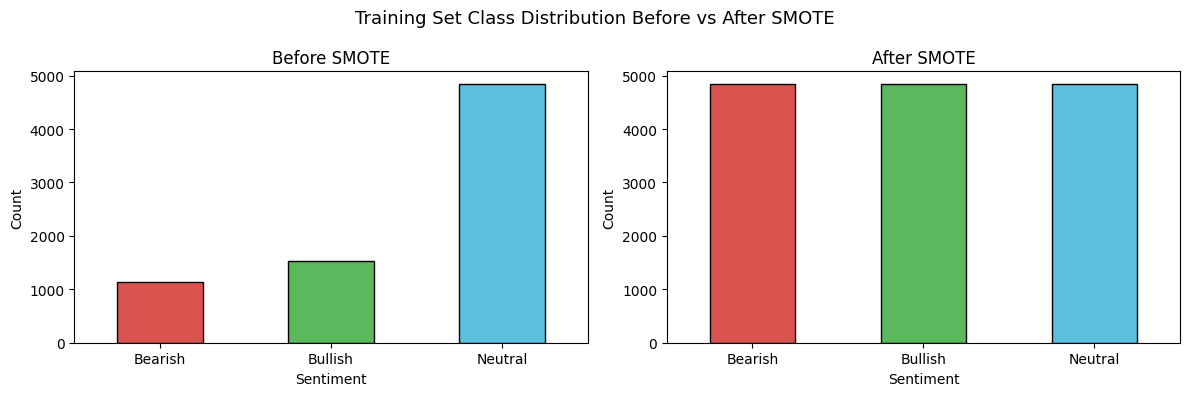

Saved: week2_smote_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


before_counts = pd.Series(y_train).value_counts().sort_index()
before_counts.rename(index=LABEL_MAP).plot(
    kind="bar",
    ax=axes[0],
    color=["#d9534f", "#5cb85c", "#5bc0de"],
    edgecolor="black"
)
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)


after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
after_counts.rename(index=LABEL_MAP).plot(
    kind="bar",
    ax=axes[1],
    color=["#d9534f", "#5cb85c", "#5bc0de"],
    edgecolor="black"
)
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Training Set Class Distribution Before vs After SMOTE", fontsize=13)
plt.tight_layout()
plt.savefig("week2_smote_comparison.png")
plt.show()
print("Saved: week2_smote_comparison.png")

In [14]:

train_df.to_csv("train_set.csv", index=False)
val_df.to_csv("val_set.csv", index=False)

print("Saved splits:")
print(f"  train_set.csv  — {len(train_df)} original rows")
print(f"  val_set.csv    — {len(val_df)} rows")
print(f"  test_set.csv   — {len(test_df)} rows (locked)")
print(f"\nSMOTE resampled training data:")
print(f"  X_train_resampled shape: {X_train_resampled.shape}")
print(f"  y_train_resampled shape: {y_train_resampled.shape}")
print(f"\nNote: X_train_resampled and y_train_resampled are in memory")
print(f"They will be used directly in Day 2 model training.")

Saved splits:
  train_set.csv  — 7504 original rows
  val_set.csv    — 938 rows
  test_set.csv   — 938 rows (locked)

SMOTE resampled training data:
  X_train_resampled shape: (14514, 4076)
  y_train_resampled shape: (14514,)

Note: X_train_resampled and y_train_resampled are in memory
They will be used directly in Day 2 model training.


In [15]:
files = [
    "train_set.csv",
    "val_set.csv",
    "test_set.csv",
    "week2_split_distribution.png",
    "week2_smote_comparison.png"
]

print("=== Day 1 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

=== Day 1 Output Files ===

EXISTS — train_set.csv (2,108,914 bytes)
EXISTS — val_set.csv (264,972 bytes)
EXISTS — test_set.csv (262,428 bytes)
EXISTS — week2_split_distribution.png (29,106 bytes)
EXISTS — week2_smote_comparison.png (23,084 bytes)


In [16]:

X_val_tfidf = vectorizer_smote.transform(val_df["cleaned_text"])
X_test_tfidf = vectorizer_smote.transform(test_df["cleaned_text"])

y_val = val_df["label"].values
y_test = test_df["label"].values

print(f"X_val_tfidf shape:  {X_val_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")
print(f"y_val shape:        {y_val.shape}")
print(f"y_test shape:       {y_test.shape}")
print(f"\nAll use same vocabulary as training set ")

X_val_tfidf shape:  (938, 4076)
X_test_tfidf shape: (938, 4076)
y_val shape:        (938,)
y_test shape:       (938,)

All use same vocabulary as training set 


In [17]:
import pickle


with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer_smote, f)

print("Saved: tfidf_vectorizer.pkl")


with open("tfidf_vectorizer.pkl", "rb") as f:
    loaded_vectorizer = pickle.load(f)


test_text = ["stock market beats earnings estimates"]
test_vec = loaded_vectorizer.transform(test_text)
print(f"Vectorizer verified — test vector shape: {test_vec.shape}")
print(f"Vocabulary size: {len(loaded_vectorizer.vocabulary_)}")

Saved: tfidf_vectorizer.pkl
Vectorizer verified — test vector shape: (1, 4076)
Vocabulary size: 4076


In [18]:
files = [
    "train_set.csv",
    "val_set.csv",
    "test_set.csv",
    "tfidf_vectorizer.pkl",
    "week2_split_distribution.png",
    "week2_smote_comparison.png"
]

print("=== Day 1 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

=== Day 1 Output Files ===

EXISTS — train_set.csv (2,108,914 bytes)
EXISTS — val_set.csv (264,972 bytes)
EXISTS — test_set.csv (262,428 bytes)
EXISTS — tfidf_vectorizer.pkl (147,614 bytes)
EXISTS — week2_split_distribution.png (29,106 bytes)
EXISTS — week2_smote_comparison.png (23,084 bytes)


Week 2 Day 2: TF-IDF + Logistic Regression Baseline Model


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

print("All imports successful")

All imports successful


In [20]:

train_df = pd.read_csv("train_set.csv")
val_df   = pd.read_csv("val_set.csv")
test_df  = pd.read_csv("test_set.csv")


with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

print("Day 1 outputs loaded successfully")
print(f"Train:      {len(train_df)} rows")
print(f"Validation: {len(val_df)} rows")
print(f"Test:       {len(test_df)} rows (locked)")
print(f"Vectorizer vocabulary size: {len(vectorizer.vocabulary_)}")

Day 1 outputs loaded successfully
Train:      7504 rows
Validation: 938 rows
Test:       938 rows (locked)
Vectorizer vocabulary size: 4076


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

X_train_tfidf = vectorizer.transform(train_df["cleaned_text"])
X_val_tfidf   = vectorizer.transform(val_df["cleaned_text"])
X_test_tfidf  = vectorizer.transform(test_df["cleaned_text"])

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_tfidf, y_train
)

print(f"X_train_resampled: {X_train_resampled.shape}")
print(f"X_val_tfidf:       {X_val_tfidf.shape}")
print(f"X_test_tfidf:      {X_test_tfidf.shape}")
print(f"\nClass counts after SMOTE:")
for lbl in sorted(np.unique(y_train_resampled)):
    count = (y_train_resampled == lbl).sum()
    print(f"  {LABEL_MAP[lbl]}: {count}")

X_train_resampled: (14514, 4076)
X_val_tfidf:       (938, 4076)
X_test_tfidf:      (938, 4076)

Class counts after SMOTE:
  Bearish: 4838
  Bullish: 4838
  Neutral: 4838


In [24]:
print("Training Logistic Regression model...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    C=1.0,
    solver="lbfgs"
)

lr_model.fit(X_train_resampled, y_train_resampled)

print("Model trained successfully")
print(f"Classes: {lr_model.classes_}")
print(f"Number of iterations: {lr_model.n_iter_}")

Training Logistic Regression model...
Model trained successfully
Classes: [0 1 2]
Number of iterations: [45]


In [25]:

y_val_pred = lr_model.predict(X_val_tfidf)


accuracy = accuracy_score(y_val, y_val_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")


print("Classification Report ")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["Bearish", "Bullish", "Neutral"]
))

Overall Accuracy: 0.7719 (77.19%)

Classification Report 
              precision    recall  f1-score   support

     Bearish       0.53      0.60      0.56       142
     Bullish       0.68      0.66      0.67       191
     Neutral       0.86      0.85      0.86       605

    accuracy                           0.77       938
   macro avg       0.69      0.70      0.70       938
weighted avg       0.78      0.77      0.77       938



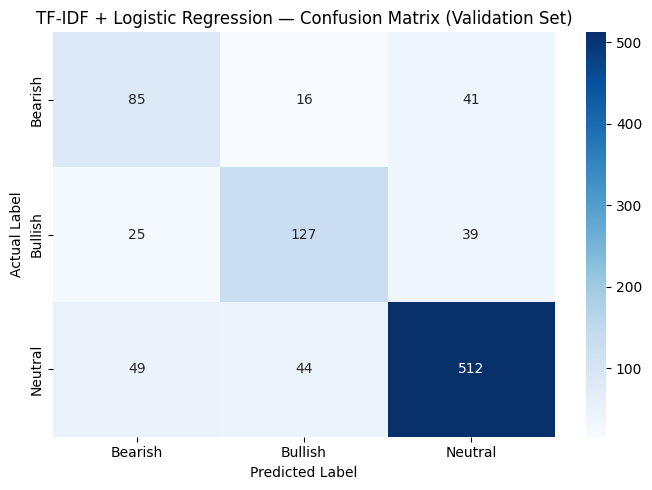

Saved: week2_tfidf_confusion_matrix.png


In [26]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bearish", "Bullish", "Neutral"],
    yticklabels=["Bearish", "Bullish", "Neutral"]
)
plt.title("TF-IDF + Logistic Regression — Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("week2_tfidf_confusion_matrix.png")
plt.show()
print("Saved: week2_tfidf_confusion_matrix.png")

In [27]:

val_df_analysis = val_df.copy()
val_df_analysis["predicted"] = y_val_pred
val_df_analysis["correct"] = val_df_analysis["label"] == val_df_analysis["predicted"]
val_df_analysis["predicted_name"] = val_df_analysis["predicted"].map(LABEL_MAP)
val_df_analysis["actual_name"] = val_df_analysis["label"].map(LABEL_MAP)


total = len(val_df_analysis)
correct = val_df_analysis["correct"].sum()
wrong = total - correct
print(f"Total validation rows: {total}")
print(f"Correctly predicted:   {correct} ({correct/total*100:.1f}%)")
print(f"Wrongly predicted:     {wrong} ({wrong/total*100:.1f}%)")


print(f"\nPer class accuracy:")
for lbl in sorted(val_df_analysis["label"].unique()):
    subset = val_df_analysis[val_df_analysis["label"] == lbl]
    acc = subset["correct"].mean() * 100
    print(f"  {LABEL_MAP[lbl]}: {acc:.1f}% correct ({len(subset)} rows)")

Total validation rows: 938
Correctly predicted:   724 (77.2%)
Wrongly predicted:     214 (22.8%)

Per class accuracy:
  Bearish: 59.9% correct (142 rows)
  Bullish: 66.5% correct (191 rows)
  Neutral: 84.6% correct (605 rows)


In [28]:

print(" Most Common Misclassifications ")
errors = val_df_analysis[val_df_analysis["correct"] == False]

error_pairs = errors.groupby(
    ["actual_name", "predicted_name"]
).size().reset_index(name="count").sort_values("count", ascending=False)

print(error_pairs.to_string(index=False))

print(f"\nSample misclassified headlines:\n")
for _, row in errors.head(5).iterrows():
    print(f"  Text:      {row['text'][:80]}...")
    print(f"  Actual:    {row['actual_name']}")
    print(f"  Predicted: {row['predicted_name']}")
    print()

 Most Common Misclassifications 
actual_name predicted_name  count
    Neutral        Bearish     49
    Neutral        Bullish     44
    Bearish        Neutral     41
    Bullish        Neutral     39
    Bullish        Bearish     25
    Bearish        Bullish     16

Sample misclassified headlines:

  Text:      $SPCE - Virgin Galactic takes off again; +11% https://t.co/on2VqYzlIM...
  Actual:    Bullish
  Predicted: Bearish

  Text:      Exclusive: UK's Labour sticks to 'basic' $20 cyber defense after attacks, emails...
  Actual:    Neutral
  Predicted: Bearish

  Text:      Probability of a recession pretty low: strategist...
  Actual:    Bullish
  Predicted: Bearish

  Text:      Greenhouse gas emissions in the U.S. are forecast to decline by a whopping 7.5% ...
  Actual:    Neutral
  Predicted: Bearish

  Text:      $AMBA - Ambarella Will Be Hard Pressed To Keep Going At Its Current Pace. Read m...
  Actual:    Bearish
  Predicted: Neutral



In [29]:

feature_names = vectorizer.get_feature_names_out()

print("Top 15 Words Per Class (Model Learned) ")
for i, label_name in enumerate(["Bearish", "Bullish", "Neutral"]):
    
    coef = lr_model.coef_[i]
    
    top_indices = coef.argsort()[-15:][::-1]
    top_words = [(feature_names[j], coef[j]) for j in top_indices]
    
    print(f"{label_name} — top signal words:")
    for word, score in top_words:
        print(f"  {word}: {score:.3f}")
    print()

Top 15 Words Per Class (Model Learned) 
Bearish — top signal words:
  down: 5.405
  downgraded: 5.297
  lower: 5.114
  misses: 4.551
  falls: 3.925
  cut: 3.392
  cuts: 3.386
  loss: 3.039
  sues: 2.993
  below: 2.968
  weak: 2.757
  pain: 2.605
  hit: 2.597
  warns: 2.450
  fall: 2.361

Bullish — top signal words:
  raised: 4.916
  up: 4.861
  beats: 3.940
  higher: 3.929
  bullish: 3.413
  rises: 3.409
  jump: 3.395
  gain: 3.339
  pre: 3.189
  beat: 3.117
  upgraded: 3.105
  rose: 2.994
  positive: 2.937
  strong: 2.840
  upside: 2.789

Neutral — top signal words:
  declares: 2.844
  marketscreener: 2.736
  do: 2.103
  how: 1.981
  2019: 1.917
  preview: 1.829
  does: 1.828
  reports: 1.788
  you: 1.787
  what: 1.716
  biggest: 1.701
  but: 1.663
  trump: 1.620
  changed: 1.617
  his: 1.572



In [30]:
# save trained model
with open("tfidf_lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Saved: tfidf_lr_model.pkl")

# verify it loads correctly
with open("tfidf_lr_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_val_tfidf[:5])
print(f"Model verified — sample predictions: {[LABEL_MAP[p] for p in test_pred]}")

Saved: tfidf_lr_model.pkl
Model verified — sample predictions: ['Neutral', 'Neutral', 'Bearish', 'Bearish', 'Neutral']


In [31]:
def predict_sentiment (text,vectorizer,model):
    vec=vectorizer.transform([text])
    pred=model.predict(vec)[0]
    proba=model.predict_proba(vec)[0]
    confidence=proba.max()
    return {
        "text": text,
        "predicted_label":int(pred),
        "predicted_sentiment": LABEL_MAP[pred],
        "confidence":f"{confidence*100:.1f}%",
        "scores":{
            LABEL_MAP[i]:f"{proba[i]*100: .1f}%"
            for i in range(3)
        }
    }
test_headlines = [
    "$AAPL beats earnings estimates revenue up 12%",
    "$TSLA misses revenue target stock falls after hours",
    "Federal Reserve announces interest rate decision next week",
    "$MSFT price target raised by analysts strong buy rating",
    "Oil prices drop amid global demand concerns coronavirus",
]

print("=== Real Headline Predictions ===\n")
for headline in test_headlines:
    result = predict_sentiment(headline, vectorizer, lr_model)
    print(f"Text:      {result['text']}")
    print(f"Predicted: {result['predicted_sentiment']} ({result['confidence']})")
    print(f"Scores:    {result['scores']}")
    print()

=== Real Headline Predictions ===

Text:      $AAPL beats earnings estimates revenue up 12%
Predicted: Bullish (98.7%)
Scores:    {'Bearish': ' 0.3%', 'Bullish': ' 98.7%', 'Neutral': ' 1.0%'}

Text:      $TSLA misses revenue target stock falls after hours
Predicted: Bearish (97.9%)
Scores:    {'Bearish': ' 97.9%', 'Bullish': ' 1.8%', 'Neutral': ' 0.4%'}

Text:      Federal Reserve announces interest rate decision next week
Predicted: Neutral (86.3%)
Scores:    {'Bearish': ' 2.7%', 'Bullish': ' 10.9%', 'Neutral': ' 86.3%'}

Text:      $MSFT price target raised by analysts strong buy rating
Predicted: Bullish (99.4%)
Scores:    {'Bearish': ' 0.4%', 'Bullish': ' 99.4%', 'Neutral': ' 0.2%'}

Text:      Oil prices drop amid global demand concerns coronavirus
Predicted: Bearish (98.1%)
Scores:    {'Bearish': ' 98.1%', 'Bullish': ' 1.0%', 'Neutral': ' 0.9%'}



In [32]:
files = [
    "train_set.csv",
    "val_set.csv",
    "test_set.csv",
    "tfidf_vectorizer.pkl",
    "tfidf_lr_model.pkl",
    "week2_tfidf_confusion_matrix.png",
    "week2_split_distribution.png",
    "week2_smote_comparison.png"
]

print("Day 2 Output Files ")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

Day 2 Output Files 
EXISTS — train_set.csv (2,108,914 bytes)
EXISTS — val_set.csv (264,972 bytes)
EXISTS — test_set.csv (262,428 bytes)
EXISTS — tfidf_vectorizer.pkl (147,614 bytes)
EXISTS — tfidf_lr_model.pkl (98,578 bytes)
EXISTS — week2_tfidf_confusion_matrix.png (25,995 bytes)
EXISTS — week2_split_distribution.png (29,106 bytes)
EXISTS — week2_smote_comparison.png (23,084 bytes)


In [33]:

val_df_analysis = val_df.copy()
val_df_analysis["predicted"] = y_val_pred
val_df_analysis["correct"] = val_df_analysis["label"] == val_df_analysis["predicted"]
val_df_analysis["predicted_name"] = val_df_analysis["predicted"].map(LABEL_MAP)
val_df_analysis["actual_name"] = val_df_analysis["label"].map(LABEL_MAP)


misclassified = val_df_analysis[val_df_analysis["correct"] == False]
misclassified.to_csv("tfidf_misclassified.csv", index=False)

print(f"Misclassified examples saved: tfidf_misclassified.csv")
print(f"Total misclassified: {len(misclassified)} rows")
print(f"\nBreakdown:")
error_pairs = misclassified.groupby(
    ["actual_name", "predicted_name"]
).size().reset_index(name="count").sort_values("count", ascending=False)
print(error_pairs.to_string(index=False))

Misclassified examples saved: tfidf_misclassified.csv
Total misclassified: 214 rows

Breakdown:
actual_name predicted_name  count
    Neutral        Bearish     49
    Neutral        Bullish     44
    Bearish        Neutral     41
    Bullish        Neutral     39
    Bullish        Bearish     25
    Bearish        Bullish     16


day 3 - DistilBERT Setup + Tokenization


In [34]:
import torch
print(torch.__version__ if hasattr(torch, '__version__') else "torch not installed")
print(f"GPU available: {torch.cuda.is_available() if 'torch' in dir() else 'unknown'}")

ModuleNotFoundError: No module named 'torch'

In [35]:
import platform
import os

print(f"Operating System: {platform.system()} {platform.version()}")
print(f"Processor: {platform.processor()}")
print(f"Machine: {platform.machine()}")

# check RAM
import psutil
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.1f} GB")
print(f"Available RAM: {ram.available / (1024**3):.1f} GB")

Operating System: Windows 10.0.26100
Processor: Intel64 Family 6 Model 186 Stepping 3, GenuineIntel
Machine: AMD64
Total RAM: 15.7 GB
Available RAM: 2.7 GB


In [37]:
import psutil
ram = psutil.virtual_memory()
print(f"Available RAM: {ram.available / (1024**3):.1f} GB")

Available RAM: 4.0 GB


In [38]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "torch", "torchvision", "torchaudio",
     "--index-url", "https://download.pytorch.org/whl/cpu"],
    capture_output=True,
    text=True
)
print(result.stdout[-1000:] if len(result.stdout) > 1000 else result.stdout)
print(result.stderr[-500:] if result.stderr else "")
print("PyTorch installation complete")

/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ----------------------------------- ---- 8/9 [torchvision]
   ---------------------------------------- 9/9 [torchvision]



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

PyTorch installation complete


In [39]:
import subprocess
import sys

result2 = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "transformers", "datasets"],
    capture_output=True,
    text=True
)
print(result2.stdout[-500:] if len(result2.stdout) > 500 else result2.stdout)
print("Transformers installation complete")

9/29 [transformers]


Transformers installation complete


In [40]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

print(f"PyTorch version:       {torch.__version__}")
print(f"Transformers version:  {__import__('transformers').__version__}")
print(f"GPU available:         {torch.cuda.is_available()}")
print(f"Device:                {'cuda' if torch.cuda.is_available() else 'cpu'}")
print("\nAll libraries ready for DistilBERT ")

PyTorch version:       2.12.1+cpu
Transformers version:  5.13.0
GPU available:         False
Device:                cpu

All libraries ready for DistilBERT 


In [41]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
NUM_LABELS = 3
MAX_LENGTH = 23     
BATCH_SIZE = 16      
RANDOM_SEED = 42


torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Max length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")
print("All imports successful")

Device: cpu
Max length: 23
Batch size: 16
All imports successful


In [43]:
train_df =pd.read_csv("train_set.csv")
val_df = pd.read_csv("val_set.csv")
test_df =pd.read_csv("test_set.csv")
print(f"Train:{len(train_df)}rows")
print(f"Validation:{len(val_df)}rows")
print(f"Test:{len(test_df)} rows (locked until Day5)")
print(f"\n Train label distribution :")
for lbl, count in train_df["label"].value_counts().sort_index().items():
    print(f"{LABEL_MAP[lbl]}: {count}")

Train:7504rows
Validation:938rows
Test:938 rows (locked until Day5)

 Train label distribution :
Bearish: 1143
Bullish: 1523
Neutral: 4838


In [44]:
print("Loading DistilBERT tokenizer...")
print("This will download the tokenizer files on first run (~250KB)")

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print(f"Tokenizer loaded successfully")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Model max length: {tokenizer.model_max_length}")

Loading DistilBERT tokenizer...
This will download the tokenizer files on first run (~250KB)


Tokenizer loaded successfully
Vocabulary size: 30522
Model max length: 512


In [45]:

sample = "$AAPL beats earnings estimates revenue up 12%"


tokens = tokenizer.tokenize(sample)
print(f"Original text: {sample}")
print(f"Tokens:        {tokens}")
print(f"Token count:   {len(tokens)}")

Original text: $AAPL beats earnings estimates revenue up 12%
Tokens:        ['$', 'aa', '##pl', 'beats', 'earnings', 'estimates', 'revenue', 'up', '12', '%']
Token count:   10


In [47]:
encoding=tokenizer(
    sample,
    max_length=MAX_LENGTH,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)
print(f"input_ids shape:{encoding['input_ids'].shape}")
print(f"attention_mask shape:{encoding['attention_mask'].shape}")
print(f"\ninput_idsm: {encoding['input_ids'][0].tolist()}")
print(f"attention_mask: {encoding['attention_mask'][0].tolist()}")
decoded=tokenizer.decode(encoding['input_ids'][0])
print(f"\nDecoded back: {decoded}")

input_ids shape:torch.Size([1, 23])
attention_mask shape:torch.Size([1, 23])

input_idsm: [101, 1002, 9779, 24759, 10299, 16565, 10035, 6599, 2039, 2260, 1003, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decoded back: [CLS] $ aapl beats earnings estimates revenue up 12 % [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [49]:
print("Distilbert special tokens")
print(f"[CLS] token id:{tokenizer.cls_token_id}")
print(f"[SEP] token id: {tokenizer.sep_token_id}")
print(f"[PAD] token id: {tokenizer.pad_token_id}")

print(f"\n What they mean:")
print(f"DistilBERT uses this token's output for classification ")
print(f"[SEP]=Separator token- marks end of sentence")
print(f"[PAD]=Padding token- fills empty spaces to reach max_length")

ids=encoding['input_ids'][0].tolist()
mask=encoding['attention_mask'][0].tolist()
print(f"Your encoding breakdowns:")
print(f"Position 0: {ids[0]}= [CLS] token ")
print(f"Position 1 -{mask.count(1)-2}:actual text tokens")
print(f"Position {mask.count(1)-1}:{ids[mask.count(1)-1]}=[SEP] token")
if 0 in mask:
    print(f"Position{mask.count(1)}-{MAX_LENGTH-1}:padding tokens")

Distilbert special tokens
[CLS] token id:101
[SEP] token id: 102
[PAD] token id: 0

 What they mean:
DistilBERT uses this token's output for classification 
[SEP]=Separator token- marks end of sentence
[PAD]=Padding token- fills empty spaces to reach max_length
Your encoding breakdowns:
Position 0: 101= [CLS] token 
Position 1 -10:actual text tokens
Position 11:102=[SEP] token
Position12-22:padding tokens


In [51]:
print(" Tokenization Examples ")

test_headlines = [
    "$AAPL beats earnings estimates",
    "$TSLA misses revenue target falls",
    "Federal Reserve announces rate decision",
    "$MSFT $GOOGL both report strong quarterly results above expectations"
]

for headline in test_headlines:
    enc = tokenizer(
        headline,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True
    )
    real_tokens = enc["attention_mask"].count(1)
    padding = enc["attention_mask"].count(0)
    truncated = len(tokenizer.tokenize(headline)) > MAX_LENGTH - 2

    print(f"Text:      {headline}")
    print(f"Real tokens (including [CLS] and [SEP]): {real_tokens}")
    print(f"Padding tokens: {padding}")
    print(f"Truncated: {truncated}")
    print()

 Tokenization Examples 
Text:      $AAPL beats earnings estimates
Real tokens (including [CLS] and [SEP]): 8
Padding tokens: 15
Truncated: False

Text:      $TSLA misses revenue target falls
Real tokens (including [CLS] and [SEP]): 9
Padding tokens: 14
Truncated: False

Text:      Federal Reserve announces rate decision
Real tokens (including [CLS] and [SEP]): 7
Padding tokens: 16
Truncated: False

Text:      $MSFT $GOOGL both report strong quarterly results above expectations
Real tokens (including [CLS] and [SEP]): 15
Padding tokens: 8
Truncated: False



In [57]:
class FinancialSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])    # ← self.texts not self.text
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(label, dtype=torch.long)
        }

print("FinancialSentimentDataset class defined successfully")

FinancialSentimentDataset class defined successfully


In [58]:

train_dataset = FinancialSentimentDataset(
    texts      = train_df["cleaned_text"].values,
    labels     = train_df["label"].values,
    tokenizer  = tokenizer,
    max_length = MAX_LENGTH
)

val_dataset = FinancialSentimentDataset(
    texts      = val_df["cleaned_text"].values,
    labels     = val_df["label"].values,
    tokenizer  = tokenizer,
    max_length = MAX_LENGTH
)

test_dataset = FinancialSentimentDataset(
    texts      = test_df["cleaned_text"].values,
    labels     = test_df["label"].values,
    tokenizer  = tokenizer,
    max_length = MAX_LENGTH
)

print(f"Train dataset:      {len(train_dataset)} items")
print(f"Validation dataset: {len(val_dataset)} items")
print(f"Test dataset:       {len(test_dataset)} items")

Train dataset:      7504 items
Validation dataset: 938 items
Test dataset:       938 items


In [59]:
# get one item from dataset and verify its format
sample_item = train_dataset[0]

print("=== Single Dataset Item ===\n")
print(f"Keys:           {list(sample_item.keys())}")
print(f"input_ids:      {sample_item['input_ids']}")
print(f"attention_mask: {sample_item['attention_mask']}")
print(f"label:          {sample_item['label']}")
print(f"\ninput_ids shape:      {sample_item['input_ids'].shape}")
print(f"attention_mask shape: {sample_item['attention_mask'].shape}")
print(f"label shape:          {sample_item['label'].shape}")

# decode input_ids back to text
decoded = tokenizer.decode(sample_item['input_ids'])
print(f"\nDecoded text: {decoded}")
print(f"Actual label: {LABEL_MAP[sample_item['label'].item()]}")

=== Single Dataset Item ===

Keys:           ['input_ids', 'attention_mask', 'label']
input_ids:      tensor([  101,  5493, 24051,  1997, 14255,  2869, 16565,  3034,  2655,  2030,
         8312,  2340,  1011, 13292,  1011,  2539,  1015, 27995, 13938,  2102,
          102,     0,     0])
attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0])
label:          2

input_ids shape:      torch.Size([23])
attention_mask shape: torch.Size([23])
label shape:          torch.Size([])

Decoded text: [CLS] edited transcript of pirs earnings conference call or presentation 11 - nov - 19 1 00pm gmt [SEP] [PAD] [PAD]
Actual label: Neutral


In [60]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,        
    num_workers=0       
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")
print(f"Batch size:         {BATCH_SIZE}")
print(f"Items per train batch × batches = {BATCH_SIZE} × {len(train_loader)} = {BATCH_SIZE * len(train_loader)}")

Train batches:      469
Validation batches: 59
Test batches:       59
Batch size:         16
Items per train batch × batches = 16 × 469 = 7504


In [61]:

batch = next(iter(train_loader))

print("=== Single Batch Verification ===\n")
print(f"Batch keys:              {list(batch.keys())}")
print(f"input_ids shape:         {batch['input_ids'].shape}")
print(f"attention_mask shape:    {batch['attention_mask'].shape}")
print(f"labels shape:            {batch['label'].shape}")
print(f"\nLabel distribution in this batch:")
for lbl in batch['label'].unique():
    count = (batch['label'] == lbl).sum().item()
    print(f"  {LABEL_MAP[lbl.item()]}: {count}")

=== Single Batch Verification ===

Batch keys:              ['input_ids', 'attention_mask', 'label']
input_ids shape:         torch.Size([16, 23])
attention_mask shape:    torch.Size([16, 23])
labels shape:            torch.Size([16])

Label distribution in this batch:
  Bearish: 2
  Bullish: 4
  Neutral: 10


In [62]:
print("=== Day 3 Readiness Check ===\n")

checks = {
    "PyTorch installed":           torch.__version__ is not None,
    "Tokenizer loaded":            tokenizer is not None,
    "Train dataset created":       len(train_dataset) == len(train_df),
    "Val dataset created":         len(val_dataset) == len(val_df),
    "Test dataset created":        len(test_dataset) == len(test_df),
    "Train loader created":        len(train_loader) > 0,
    "Val loader created":          len(val_loader) > 0,
    "Correct max_length":          MAX_LENGTH == 23,
    "Correct batch size":          BATCH_SIZE == 16,
    "Correct device":              str(DEVICE) == "cpu",
}

all_passed = True
for check, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {check}")

print()
if all_passed:
    print("All checks passed. Ready for Day 4 DistilBERT training.")
else:
    print("Some checks failed — fix before Day 4.")

=== Day 3 Readiness Check ===

  [PASS] PyTorch installed
  [PASS] Tokenizer loaded
  [PASS] Train dataset created
  [PASS] Val dataset created
  [PASS] Test dataset created
  [PASS] Train loader created
  [PASS] Val loader created
  [PASS] Correct max_length
  [PASS] Correct batch size
  [PASS] Correct device

All checks passed. Ready for Day 4 DistilBERT training.


day 4


In [63]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

LABEL_MAP     = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
NUM_LABELS    = 3
MAX_LENGTH    = 23
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-5
RANDOM_SEED   = 42
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Device:        {DEVICE}")
print(f"Epochs:        {EPOCHS}")
print(f"Batch size:    {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Max length:    {MAX_LENGTH}")
print("All imports successful")

Device:        cpu
Epochs:        3
Batch size:    16
Learning rate: 2e-05
Max length:    23
All imports successful


In [64]:
train_df = pd.read_csv("train_set.csv")
val_df   = pd.read_csv("val_set.csv")
test_df  = pd.read_csv("test_set.csv")

print(f"Train:      {len(train_df)} rows")
print(f"Validation: {len(val_df)} rows")
print(f"Test:       {len(test_df)} rows (locked until Day 5)")

Train:      7504 rows
Validation: 938 rows
Test:       938 rows (locked until Day 5)


In [65]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
print(f"Tokenizer loaded — vocabulary size: {tokenizer.vocab_size}")

Tokenizer loaded — vocabulary size: 30522


In [66]:
class FinancialSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(label, dtype=torch.long)
        }

print("Dataset class defined successfully")

Dataset class defined successfully


In [68]:
train_dataset = FinancialSentimentDataset(
    train_df["cleaned_text"].values,
    train_df["label"].values,
    tokenizer,MAX_LENGTH
)
val_dataset = FinancialSentimentDataset(
    val_df["cleaned_text"].values,
    val_df["label"].values,
    tokenizer,MAX_LENGTH
)
test_dataset = FinancialSentimentDataset(
    test_df["cleaned_text"].values,
    test_df["label"].values,
    tokenizer, MAX_LENGTH
)
train_loader = DataLoader(
    train_dataset,batch_size=BATCH_SIZE,
    shuffle=True,num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0
)
print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train batches:      469
Validation batches: 59
Test batches:       59


In [69]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1,2]),
    y=train_df["label"].values
)
class_weights_tensor= torch.tensor(
    class_weights,
    dtype=torch.float,
).to(DEVICE)
print("Class weights computed:")
for i, weight in enumerate(class_weights):
    print(f"  {LABEL_MAP[i]}: {weight:.4f}")
print(f"\nTensor: {class_weights_tensor}")

Class weights computed:
  Bearish: 2.1884
  Bullish: 1.6424
  Neutral: 0.5170

Tensor: tensor([2.1884, 1.6424, 0.5170])


In [70]:
print("Loading pretrained DistilBERT model...")
print("This will download model weights on first run (~250MB)")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
)

model = model.to(DEVICE)


total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel loaded successfully")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model device:         {next(model.parameters()).device}")

Loading pretrained DistilBERT model...
This will download model weights on first run (~250MB)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8446.38it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded successfully
Total parameters:     66,955,779
Trainable parameters: 66,955,779
Model device:         cpu


In [71]:
from torch.optim import AdamW
optimizer= AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)
total_steps=len(train_loader)*EPOCHS
warmup_steps=int(0.1* total_steps)

scheduler=get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f"Optimizer:    AdamW")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Total steps:   {total_steps}")
print(f"Warmup steps:  {warmup_steps}")

Optimizer:    AdamW
Learning rate: 2e-05
Total steps:   1407
Warmup steps:  140


In [72]:
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
print(f"Loss function: CrossEntropyLoss with class weights")
print(f"Class weights: {class_weights_tensor}")

Loss function: CrossEntropyLoss with class weights
Class weights: tensor([2.1884, 1.6424, 0.5170])


In [74]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

      
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits

        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} "
                  f"Loss: {loss.item():.4f} "
                  f"Acc: {correct/total*100:.1f}%")

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [75]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro")
    accuracy = sum(p == l for p, l in zip(all_predictions, all_labels)) / len(all_labels)

    return avg_loss, accuracy, macro_f1, all_predictions, all_labels

print("Training and evaluation functions defined successfully")

Training and evaluation functions defined successfully


In [76]:
print("Starting DistilBERT fine-tuning...")
print(f"Training on: {DEVICE}")
print(f"Epochs: {EPOCHS}")
print(f"Estimated time: 45-60 minutes on CPU\n")
print("=" * 60)

best_val_f1 = 0
best_epoch  = 0
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer,
        scheduler, loss_fn, DEVICE
    )

    
    val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(
        model, val_loader, loss_fn, DEVICE
    )

    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"\nEpoch {epoch+1} Results:")
    print(f"  Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}  Val Acc:   {val_acc*100:.2f}%")
    print(f"  Val Macro F1: {val_f1:.4f}")

    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch + 1
        torch.save(model.state_dict(), "distilbert_best_model.pt")
        print(f"  New best model saved (F1: {val_f1:.4f})")

print("\n" + "=" * 60)
print(f"Training complete!")
print(f"Best model: Epoch {best_epoch} with Val F1: {best_val_f1:.4f}")

Starting DistilBERT fine-tuning...
Training on: cpu
Epochs: 3
Estimated time: 45-60 minutes on CPU


Epoch 1/3
----------------------------------------
  Batch 50/469 Loss: 1.0904 Acc: 33.6%
  Batch 100/469 Loss: 0.9903 Acc: 42.8%
  Batch 150/469 Loss: 0.8250 Acc: 50.0%
  Batch 200/469 Loss: 1.0070 Acc: 55.4%
  Batch 250/469 Loss: 0.3014 Acc: 59.6%
  Batch 300/469 Loss: 0.4424 Acc: 62.2%
  Batch 350/469 Loss: 0.6497 Acc: 64.2%
  Batch 400/469 Loss: 1.0090 Acc: 66.2%
  Batch 450/469 Loss: 0.7960 Acc: 67.4%

Epoch 1 Results:
  Train Loss: 0.7653  Train Acc: 67.83%
  Val Loss:   0.5277  Val Acc:   79.53%
  Val Macro F1: 0.7540
  New best model saved (F1: 0.7540)

Epoch 2/3
----------------------------------------
  Batch 50/469 Loss: 0.3924 Acc: 85.0%
  Batch 100/469 Loss: 0.1856 Acc: 84.8%
  Batch 150/469 Loss: 0.5315 Acc: 84.1%
  Batch 200/469 Loss: 0.4273 Acc: 84.5%
  Batch 250/469 Loss: 0.9016 Acc: 84.8%
  Batch 300/469 Loss: 0.3109 Acc: 84.9%
  Batch 350/469 Loss: 0.2668 Acc: 85.1%
 

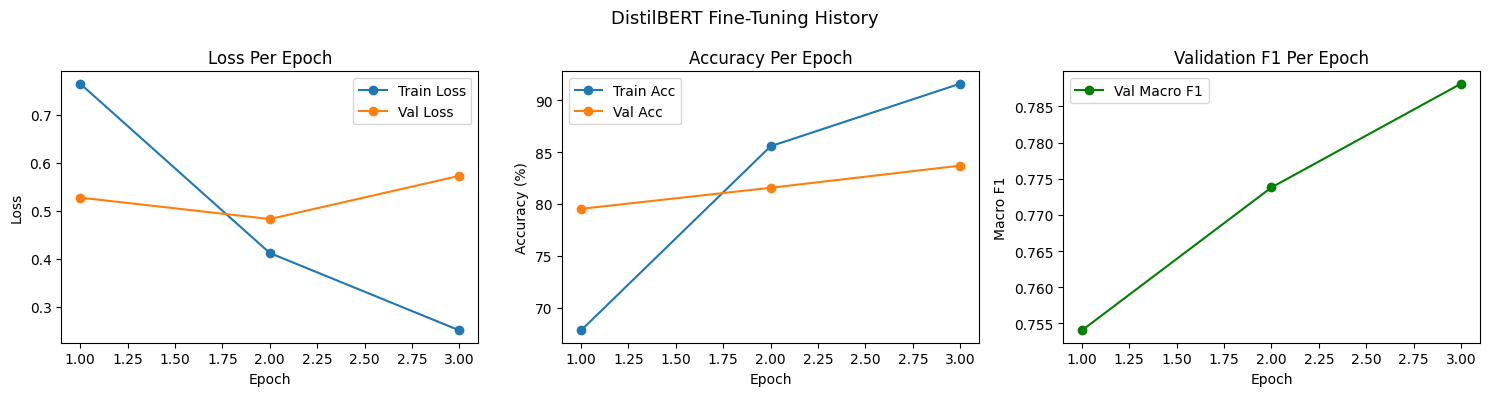

Saved: week2_distilbert_training_history.png


In [77]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].plot(range(1, EPOCHS+1), history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(range(1, EPOCHS+1), history["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_title("Loss Per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


axes[1].plot(range(1, EPOCHS+1), [a*100 for a in history["train_acc"]], label="Train Acc", marker="o")
axes[1].plot(range(1, EPOCHS+1), [a*100 for a in history["val_acc"]],   label="Val Acc",   marker="o")
axes[1].set_title("Accuracy Per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

axes[2].plot(range(1, EPOCHS+1), history["val_f1"], label="Val Macro F1", marker="o", color="green")
axes[2].set_title("Validation F1 Per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro F1")
axes[2].legend()

plt.suptitle("DistilBERT Fine-Tuning History", fontsize=13)
plt.tight_layout()
plt.savefig("week2_distilbert_training_history.png")
plt.show()
print("Saved: week2_distilbert_training_history.png")

In [78]:

model.load_state_dict(torch.load("distilbert_best_model.pt"))
model.eval()


_, val_acc, val_f1, val_preds, val_labels = evaluate(
    model, val_loader, loss_fn, DEVICE
)

print("=== Best Model — Validation Set Results ===\n")
print(f"Overall Accuracy: {val_acc*100:.2f}%")
print(f"Macro F1:         {val_f1:.4f}\n")
print(classification_report(
    val_labels,
    val_preds,
    target_names=["Bearish", "Bullish", "Neutral"]
))

=== Best Model — Validation Set Results ===

Overall Accuracy: 83.69%
Macro F1:         0.7881

              precision    recall  f1-score   support

     Bearish       0.65      0.73      0.69       142
     Bullish       0.80      0.77      0.79       191
     Neutral       0.90      0.88      0.89       605

    accuracy                           0.84       938
   macro avg       0.78      0.80      0.79       938
weighted avg       0.84      0.84      0.84       938



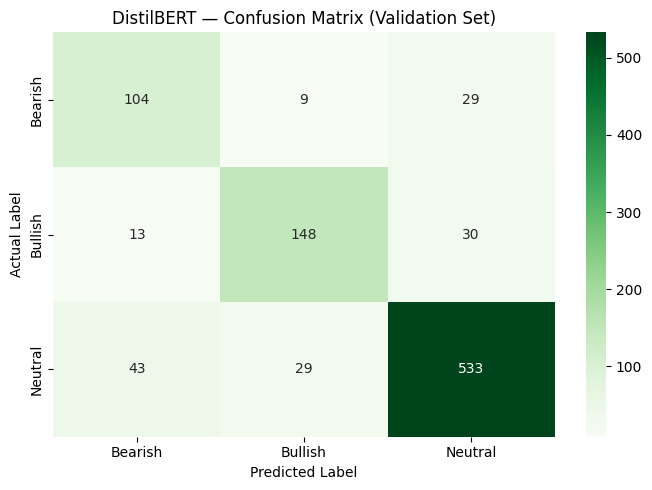

Saved: week2_distilbert_confusion_matrix.png


In [79]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Bearish", "Bullish", "Neutral"],
    yticklabels=["Bearish", "Bullish", "Neutral"]
)
plt.title("DistilBERT — Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("week2_distilbert_confusion_matrix.png")
plt.show()
print("Saved: week2_distilbert_confusion_matrix.png")

In [80]:
print("=== Model Comparison: TF-IDF vs DistilBERT ===\n")
print(f"{'Metric':<25} {'TF-IDF':>10} {'DistilBERT':>12}")
print("-" * 50)


tfidf_results = {
    "Overall Accuracy":  77.19,
    "Bearish F1":        0.56,
    "Bullish F1":        0.67,
    "Neutral F1":        0.86,
    "Macro F1":          0.70,
}


report = classification_report(
    val_labels, val_preds,
    target_names=["Bearish", "Bullish", "Neutral"],
    output_dict=True
)

distilbert_results = {
    "Overall Accuracy":  val_acc * 100,
    "Bearish F1":        report["Bearish"]["f1-score"],
    "Bullish F1":        report["Bullish"]["f1-score"],
    "Neutral F1":        report["Neutral"]["f1-score"],
    "Macro F1":          report["macro avg"]["f1-score"],
}

for metric in tfidf_results:
    tfidf_val = tfidf_results[metric]
    distil_val = distilbert_results[metric]

    if metric == "Overall Accuracy":
        improvement = distil_val - tfidf_val
        print(f"{metric:<25} {tfidf_val:>9.2f}% {distil_val:>10.2f}%  ({'+' if improvement > 0 else ''}{improvement:.2f}%)")
    else:
        improvement = distil_val - tfidf_val
        print(f"{metric:<25} {tfidf_val:>10.2f} {distil_val:>11.2f}  ({'+' if improvement > 0 else ''}{improvement:.2f})")

=== Model Comparison: TF-IDF vs DistilBERT ===

Metric                        TF-IDF   DistilBERT
--------------------------------------------------
Overall Accuracy              77.19%      83.69%  (+6.50%)
Bearish F1                      0.56        0.69  (+0.13)
Bullish F1                      0.67        0.79  (+0.12)
Neutral F1                      0.86        0.89  (+0.03)
Macro F1                        0.70        0.79  (+0.09)


In [81]:

val_df_analysis = val_df.copy()
val_df_analysis["predicted"]      = val_preds
val_df_analysis["correct"]        = val_df_analysis["label"] == val_df_analysis["predicted"]
val_df_analysis["predicted_name"] = val_df_analysis["predicted"].map(LABEL_MAP)
val_df_analysis["actual_name"]    = val_df_analysis["label"].map(LABEL_MAP)

misclassified = val_df_analysis[val_df_analysis["correct"] == False]
misclassified.to_csv("distilbert_misclassified.csv", index=False)

print(f"Misclassified examples saved: distilbert_misclassified.csv")
print(f"Total misclassified: {len(misclassified)} rows")
print(f"\nBreakdown:")
error_pairs = misclassified.groupby(
    ["actual_name", "predicted_name"]
).size().reset_index(name="count").sort_values("count", ascending=False)
print(error_pairs.to_string(index=False))

Misclassified examples saved: distilbert_misclassified.csv
Total misclassified: 153 rows

Breakdown:
actual_name predicted_name  count
    Neutral        Bearish     43
    Bullish        Neutral     30
    Neutral        Bullish     29
    Bearish        Neutral     29
    Bullish        Bearish     13
    Bearish        Bullish      9


In [82]:
files = [
    "distilbert_best_model.pt",
    "distilbert_misclassified.csv",
    "week2_distilbert_training_history.png",
    "week2_distilbert_confusion_matrix.png",
    "train_set.csv",
    "val_set.csv",
    "test_set.csv",
    "tfidf_lr_model.pkl",
    "tfidf_vectorizer.pkl",
    "tfidf_misclassified.csv",
]

print("=== Day 4 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

=== Day 4 Output Files ===

EXISTS — distilbert_best_model.pt (267,865,075 bytes)
EXISTS — distilbert_misclassified.csv (47,306 bytes)
EXISTS — week2_distilbert_training_history.png (63,088 bytes)
EXISTS — week2_distilbert_confusion_matrix.png (25,178 bytes)
EXISTS — train_set.csv (2,108,914 bytes)
EXISTS — val_set.csv (264,972 bytes)
EXISTS — test_set.csv (262,428 bytes)
EXISTS — tfidf_lr_model.pkl (98,578 bytes)
EXISTS — tfidf_vectorizer.pkl (147,614 bytes)
EXISTS — tfidf_misclassified.csv (66,207 bytes)


day 5-Final Evaluation on Locked Test Set

In [83]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

LABEL_MAP  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
NUM_LABELS = 3
MAX_LENGTH = 23
BATCH_SIZE = 16
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print("All imports successful")

Device: cpu
All imports successful


In [84]:
test_df = pd.read_csv("test_set.csv")
test_df["label"] = test_df["label"].astype(int)

print(f"Test set loaded: {len(test_df)} rows")
print(f"\nLabel distribution:")
for lbl, count in test_df["label"].value_counts().sort_index().items():
    pct = count / len(test_df) * 100
    print(f"  {LABEL_MAP[lbl]}: {count} ({pct:.1f}%)")

Test set loaded: 938 rows

Label distribution:
  Bearish: 143 (15.2%)
  Bullish: 190 (20.3%)
  Neutral: 605 (64.5%)


In [85]:

with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

with open("tfidf_lr_model.pkl", "rb") as f:
    tfidf_model = pickle.load(f)

print("TF-IDF model and vectorizer loaded successfully")
print(f"Vectorizer vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF model and vectorizer loaded successfully
Vectorizer vocabulary size: 4076


In [86]:
X_test_tfidf = vectorizer.transform(test_df["cleaned_text"])
y_test=test_df["label"].values
y_test_pred_tfidf=tfidf_model.predict(X_test_tfidf)
tfidf_accuracy=accuracy_score(y_test,y_test_pred_tfidf)
tfidf_macro_f1=f1_score(y_test,y_test_pred_tfidf,average="macro")
print("TF-IDF + Logistic Regression - Test Set Results")
print(f"Overall Accuracy:{tfidf_accuracy* 100 : .2f}%")
print(f"Macro F1:{tfidf_macro_f1: .4f}\n")
print(classification_report(
    y_test,
    y_test_pred_tfidf,
    target_names=["Bearish","Bullish","Neutral"]
) )

TF-IDF + Logistic Regression - Test Set Results
Overall Accuracy: 76.87%
Macro F1: 0.7033

              precision    recall  f1-score   support

     Bearish       0.56      0.69      0.62       143
     Bullish       0.63      0.65      0.64       190
     Neutral       0.88      0.83      0.85       605

    accuracy                           0.77       938
   macro avg       0.69      0.72      0.70       938
weighted avg       0.78      0.77      0.77       938



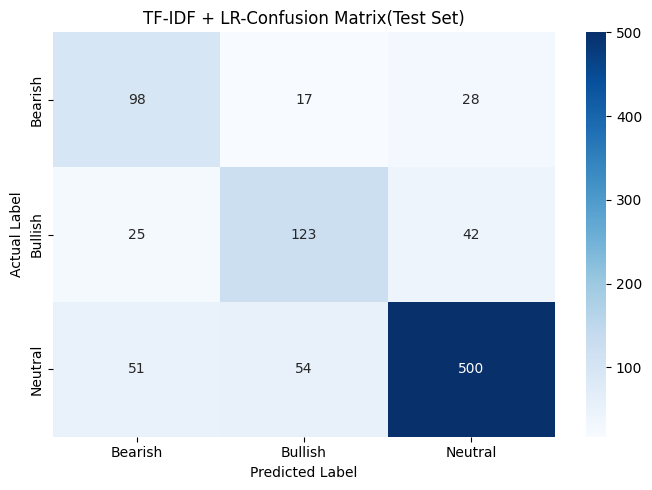

Saved: week2_final_tfidf_test_confusion.png


In [88]:
cm_tfidf = confusion_matrix(y_test, y_test_pred_tfidf)
plt.figure(figsize=(7,5))
sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bearish","Bullish","Neutral"],
    yticklabels=["Bearish","Bullish","Neutral"]
)
plt.title("TF-IDF + LR-Confusion Matrix(Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("week2_final_tfidf_test_confusion.png")
plt.show()
print("Saved: week2_final_tfidf_test_confusion.png")

In [89]:
class FinancialSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label":          torch.tensor(label, dtype=torch.long)
        }

print("Dataset class defined successfully")

Dataset class defined successfully


In [90]:
tokenizer=DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model=DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
    )
model.load_state_dict(torch.load(
    "distilbert_best_model.pt",
    map_location=DEVICE
))

model=model.to(DEVICE)
model.eval()
print("DistilBert best model loaded successfully ")
print(f"Model device:{next(model.parameters()).device}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6481.89it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBert best model loaded successfully 
Model device:cpu


In [91]:

classifier_weight = model.classifier.weight.data
print(f"Classifier weight shape: {classifier_weight.shape}")
print(f"Classifier weight mean:  {classifier_weight.mean():.6f}")
print(f"Classifier weight std:   {classifier_weight.std():.6f}")

if classifier_weight.std() < 0.001:
    print("\nWARNING: Classifier weights look random — model may not have loaded correctly")
else:
    print("\nClassifier weights look correct — model loaded successfully")

Classifier weight shape: torch.Size([3, 768])
Classifier weight mean:  -0.000339
Classifier weight std:   0.020526

Classifier weights look correct — model loaded successfully


In [92]:
test_dataset=FinancialSentimentDataset(
    test_df["cleaned_text"].values,
    test_df["label"].values,
    tokenizer,
    MAX_LENGTH
)

test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Test Dataset: {len(test_dataset)} items")
print(f"Test batches: {len(test_loader)}")

Test Dataset: 938 items
Test batches: 59


In [93]:
all_predictions =[]
all_labels=[]

with torch.no_grad():
    for batch in test_loader:
        input_ids=batch["input_ids"].to(DEVICE)
        attention_mask=batch["attention_mask"].to(DEVICE)
        labels=batch["label"].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions=torch.argmax(outputs.logits, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

distilbert_accuracy=accuracy_score(all_labels, all_predictions)
distilbert_macro_f1=f1_score(all_labels, all_predictions, average="macro")
print("DistilBERT — Test Set Results ")
print(f"Overall Accuracy: {distilbert_accuracy*100:.2f}%")
print(f"Macro F1:         {distilbert_macro_f1:.4f}\n")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["Bearish", "Bullish", "Neutral"]
))

DistilBERT — Test Set Results 
Overall Accuracy: 84.43%
Macro F1:         0.8005

              precision    recall  f1-score   support

     Bearish       0.66      0.84      0.74       143
     Bullish       0.80      0.74      0.77       190
     Neutral       0.92      0.88      0.90       605

    accuracy                           0.84       938
   macro avg       0.79      0.82      0.80       938
weighted avg       0.85      0.84      0.85       938



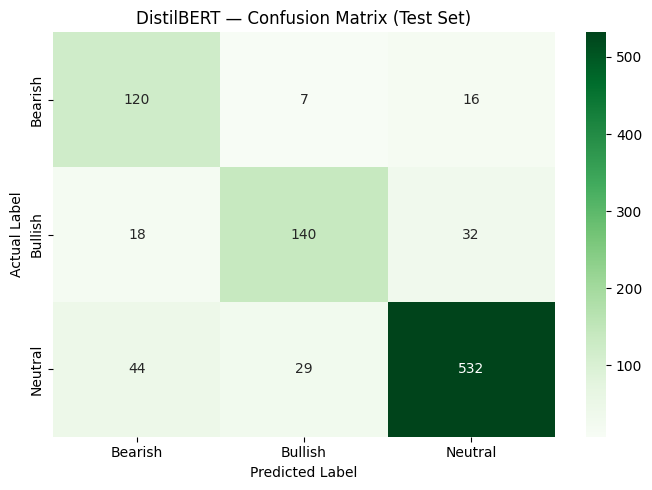

Saved: week2_final_distilbert_test_confusion.png


In [94]:
cm_distilbert = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Bearish", "Bullish", "Neutral"],
    yticklabels=["Bearish", "Bullish", "Neutral"]
)
plt.title("DistilBERT — Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("week2_final_distilbert_test_confusion.png")
plt.show()
print("Saved: week2_final_distilbert_test_confusion.png")

In [95]:

tfidf_report = classification_report(
    y_test, y_test_pred_tfidf,
    target_names=["Bearish", "Bullish", "Neutral"],
    output_dict=True
)

distilbert_report = classification_report(
    all_labels, all_predictions,
    target_names=["Bearish", "Bullish", "Neutral"],
    output_dict=True
)

print("FINAL MODEL COMPARISON — TEST SET ")
print(f"{'Metric':<25} {'TF-IDF':>10} {'DistilBERT':>12} {'Improvement':>12}")
print("-" * 62)

metrics = {
    "Overall Accuracy":  (tfidf_accuracy*100,        distilbert_accuracy*100,        True),
    "Bearish F1":        (tfidf_report["Bearish"]["f1-score"],     distilbert_report["Bearish"]["f1-score"],     False),
    "Bullish F1":        (tfidf_report["Bullish"]["f1-score"],     distilbert_report["Bullish"]["f1-score"],     False),
    "Neutral F1":        (tfidf_report["Neutral"]["f1-score"],     distilbert_report["Neutral"]["f1-score"],     False),
    "Macro F1":          (tfidf_macro_f1,             distilbert_macro_f1,             False),
    "Bearish Precision": (tfidf_report["Bearish"]["precision"],    distilbert_report["Bearish"]["precision"],    False),
    "Bearish Recall":    (tfidf_report["Bearish"]["recall"],       distilbert_report["Bearish"]["recall"],       False),
}

for metric, (tfidf_val, distil_val, is_pct) in metrics.items():
    improvement = distil_val - tfidf_val
    sign = "+" if improvement > 0 else ""
    if is_pct:
        print(f"{metric:<25} {tfidf_val:>9.2f}% {distil_val:>10.2f}%  ({sign}{improvement:.2f}%)")
    else:
        print(f"{metric:<25} {tfidf_val:>10.3f} {distil_val:>11.3f}  ({sign}{improvement:.3f})")

print(f"\nWinner: {'DistilBERT' if distilbert_macro_f1 > tfidf_macro_f1 else 'TF-IDF'}")
print(f"Selected model for predict.py: DistilBERT")

FINAL MODEL COMPARISON — TEST SET 
Metric                        TF-IDF   DistilBERT  Improvement
--------------------------------------------------------------
Overall Accuracy              76.87%      84.43%  (+7.57%)
Bearish F1                     0.618       0.738  (+0.120)
Bullish F1                     0.641       0.765  (+0.124)
Neutral F1                     0.851       0.898  (+0.047)
Macro F1                       0.703       0.800  (+0.097)
Bearish Precision              0.563       0.659  (+0.096)
Bearish Recall                 0.685       0.839  (+0.154)

Winner: DistilBERT
Selected model for predict.py: DistilBERT


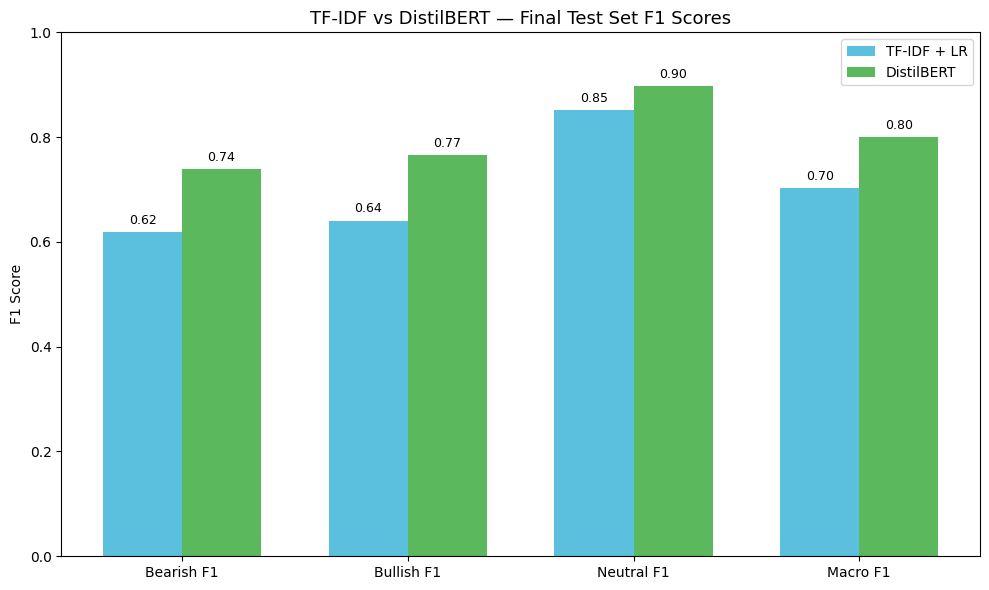

Saved: week2_final_model_comparison.png


In [96]:
categories = ["Bearish F1", "Bullish F1", "Neutral F1", "Macro F1"]
tfidf_scores = [
    tfidf_report["Bearish"]["f1-score"],
    tfidf_report["Bullish"]["f1-score"],
    tfidf_report["Neutral"]["f1-score"],
    tfidf_macro_f1
]
distilbert_scores = [
    distilbert_report["Bearish"]["f1-score"],
    distilbert_report["Bullish"]["f1-score"],
    distilbert_report["Neutral"]["f1-score"],
    distilbert_macro_f1
]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, tfidf_scores,      width, label="TF-IDF + LR",  color="#5bc0de")
bars2 = ax.bar(x + width/2, distilbert_scores, width, label="DistilBERT",   color="#5cb85c")

ax.set_title("TF-IDF vs DistilBERT — Final Test Set F1 Scores", fontsize=13)
ax.set_ylabel("F1 Score")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.0)
ax.legend()


for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("week2_final_model_comparison.png")
plt.show()
print("Saved: week2_final_model_comparison.png")

In [97]:
print("Error Analysis Comparison ")

tfidf_errors = (np.array(y_test_pred_tfidf) != np.array(y_test)).sum()
distilbert_errors = (np.array(all_predictions) != np.array(all_labels)).sum()

print(f"TF-IDF errors:     {tfidf_errors} / {len(y_test)} ({tfidf_errors/len(y_test)*100:.1f}%)")
print(f"DistilBERT errors: {distilbert_errors} / {len(all_labels)} ({distilbert_errors/len(all_labels)*100:.1f}%)")
print(f"Errors reduced:    {tfidf_errors - distilbert_errors} fewer mistakes")
print(f"Error reduction:   {(tfidf_errors-distilbert_errors)/tfidf_errors*100:.1f}%")

print(f"\nPer class error breakdown:")
print(f"\n{'Class':<10} {'TF-IDF correct':>15} {'DistilBERT correct':>20}")
print("-" * 47)
for lbl in sorted(test_df["label"].unique()):
    subset_true = np.array(y_test) == lbl
    tfidf_correct = ((np.array(y_test_pred_tfidf) == lbl) & subset_true).sum()
    distil_correct = ((np.array(all_predictions) == lbl) & subset_true).sum()
    total = subset_true.sum()
    print(f"{LABEL_MAP[lbl]:<10} {tfidf_correct}/{total} ({tfidf_correct/total*100:.1f}%)    {distil_correct}/{total} ({distil_correct/total*100:.1f}%)")

Error Analysis Comparison 
TF-IDF errors:     217 / 938 (23.1%)
DistilBERT errors: 146 / 938 (15.6%)
Errors reduced:    71 fewer mistakes
Error reduction:   32.7%

Per class error breakdown:

Class       TF-IDF correct   DistilBERT correct
-----------------------------------------------
Bearish    98/143 (68.5%)    120/143 (83.9%)
Bullish    123/190 (64.7%)    140/190 (73.7%)
Neutral    500/605 (82.6%)    532/605 (87.9%)


In [98]:
files = [
    "distilbert_best_model.pt",
    "tfidf_lr_model.pkl",
    "tfidf_vectorizer.pkl",
    "week2_final_tfidf_test_confusion.png",
    "week2_final_distilbert_test_confusion.png",
    "week2_final_model_comparison.png",
    "week2_distilbert_training_history.png",
    "tfidf_misclassified.csv",
    "distilbert_misclassified.csv",
]

print("Day 5 Output Files ")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

Day 5 Output Files 
EXISTS — distilbert_best_model.pt (267,865,075 bytes)
EXISTS — tfidf_lr_model.pkl (98,578 bytes)
EXISTS — tfidf_vectorizer.pkl (147,614 bytes)
EXISTS — week2_final_tfidf_test_confusion.png (23,765 bytes)
EXISTS — week2_final_distilbert_test_confusion.png (24,253 bytes)
EXISTS — week2_final_model_comparison.png (22,877 bytes)
EXISTS — week2_distilbert_training_history.png (63,088 bytes)
EXISTS — tfidf_misclassified.csv (66,207 bytes)
EXISTS — distilbert_misclassified.csv (47,306 bytes)


In [99]:
tokenizer.save_pretrained("distilbert_tokenizer")
print("Tokenizer saved to: distilbert_tokenizer/")

Tokenizer saved to: distilbert_tokenizer/


day 6



In [101]:
import os
import re
import torch
import numpy as np
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

LABEL_MAP  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
NUM_LABELS = 3
MAX_LENGTH = 23
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print("All imports successful")

Device: cpu
All imports successful


In [102]:
files = [
    "distilbert_best_model.pt",
    "tfidf_lr_model.pkl",
    "tfidf_vectorizer.pkl",
    "train_set.csv",
    "val_set.csv",
    "test_set.csv",
]

print("=== Checking Day 5 files ===\n")
for file in files:
    exists = os.path.exists(file)
    size = os.path.getsize(file) if exists else 0
    print(f"{'EXISTS' if exists else 'MISSING'} — {file} ({size:,} bytes)")

=== Checking Day 5 files ===

EXISTS — distilbert_best_model.pt (267,865,075 bytes)
EXISTS — tfidf_lr_model.pkl (98,578 bytes)
EXISTS — tfidf_vectorizer.pkl (147,614 bytes)
EXISTS — train_set.csv (2,108,914 bytes)
EXISTS — val_set.csv (264,972 bytes)
EXISTS — test_set.csv (262,428 bytes)


In [103]:

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


tokenizer.save_pretrained("distilbert_tokenizer")

print("Tokenizer saved to: distilbert_tokenizer/")
print(f"Files saved: {os.listdir('distilbert_tokenizer')}")

Tokenizer saved to: distilbert_tokenizer/
Files saved: ['tokenizer.json', 'tokenizer_config.json']


In [104]:
def remove_urls(text):
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"www\.\S+", "", text)
    return text.strip()

def remove_twitter_artifacts(text):
    text = re.sub(r"^RT @\w+:\s*", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.replace("&amp;", "and")
    text = text.replace("&lt;",  "<")
    text = text.replace("&gt;",  ">")
    text = text.replace("&quot;", '"')
    text = text.replace("&#39;", "'")
    text = re.sub(r"#(\w+)", r"\1", text)
    return text.strip()

def fix_encoding(text):
    try:
        text = text.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    return text.strip()

def normalize_tickers(text):
    def uppercase_ticker(match):
        return match.group(0).upper()
    text = re.sub(r"\$[a-zA-Z]{1,6}\b", uppercase_ticker, text)
    return text

def lowercase_except_tickers(text):
    tickers = re.findall(r"\$[A-Z]{1,6}\b", text)
    placeholders = {}
    for i, ticker in enumerate(tickers):
        placeholder = f"__ticker{i}__"
        placeholders[placeholder] = ticker
        text = text.replace(ticker, placeholder, 1)
    text = text.lower()
    for placeholder, ticker in placeholders.items():
        text = text.replace(placeholder, ticker)
    return text

def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z0-9\s\$\%\.\,\-\']", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def full_clean_pipeline(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[\n\t\r]", " ", text)
    text = remove_urls(text)
    text = remove_twitter_artifacts(text)
    text = fix_encoding(text)
    text = normalize_tickers(text)
    text = lowercase_except_tickers(text)
    text = remove_special_chars(text)
    return text.strip()

print("Cleaning pipeline defined successfully")

Cleaning pipeline defined successfully


In [105]:

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
)

model.load_state_dict(torch.load(
    "distilbert_best_model.pt",
    map_location=DEVICE
))

model = model.to(DEVICE)
model.eval()

print("DistilBERT model loaded successfully")
print(f"Model device: {next(model.parameters()).device}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2226.16it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully
Model device: cpu


In [106]:
def predict(text: str) -> dict:
    """
    Predict sentiment of a financial headline.
    
    Args:
        text: raw uncleaned financial headline string
        
    Returns:
        dict with keys:
            - original_text:   input text as received
            - cleaned_text:    text after cleaning pipeline
            - label:           predicted class number (0, 1, 2)
            - sentiment:       predicted class name
            - confidence:      confidence of top prediction
            - scores:          probability for all three classes
    """
    
    if not text or not isinstance(text, str):
        return {
            "error": "Invalid input — please provide a non-empty string",
            "original_text": str(text)
        }

    
    cleaned = full_clean_pipeline(text)


    if not cleaned:
        return {
            "error": "Text became empty after cleaning",
            "original_text": text,
            "cleaned_text": cleaned
        }

    
    encoding = tokenizer(
        cleaned,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits

    
    probabilities = torch.softmax(logits, dim=1)[0]
    probabilities = probabilities.cpu().numpy()

    
    predicted_label = int(np.argmax(probabilities))
    confidence      = float(probabilities[predicted_label])

    return {
        "original_text": text,
        "cleaned_text":  cleaned,
        "label":         predicted_label,
        "sentiment":     LABEL_MAP[predicted_label],
        "confidence":    f"{confidence*100:.1f}%",
        "scores": {
            LABEL_MAP[i]: f"{probabilities[i]*100:.1f}%"
            for i in range(NUM_LABELS)
        }
    }

print("predict() function defined successfully")

predict() function defined successfully


In [107]:
test_headlines = [

    "$NVDA reports record revenue smashing analyst expectations",
    
    "$META shares plunge after disappointing user growth numbers",
    
    "Apple scheduled to report quarterly earnings next Tuesday",
    
    "Economists say probability of recession has fallen significantly",
    
    "RT @marketwatch: $AAPL beats Q3 estimates &amp; raises guidance #stocks https://t.co/abc123",
    
    "$MSFT $GOOGL $AMZN all hit new 52 week highs today",
    
    "$TSLA warned investors margins will continue to compress",
    
    "$SPY down",
  
    "Federal Reserve meeting minutes released showing divided opinion",
]

print("=== predict() Test Results ===\n")
for headline in test_headlines:
    result = predict(headline)
    print(f"Input:     {headline[:70]}...")
    print(f"Cleaned:   {result.get('cleaned_text', 'N/A')[:70]}")
    print(f"Predicted: {result['sentiment']} ({result['confidence']})")
    print(f"Scores:    {result['scores']}")
    print()

=== predict() Test Results ===

Input:     $NVDA reports record revenue smashing analyst expectations...
Cleaned:   $NVDA reports record revenue smashing analyst expectations
Predicted: Bullish (98.9%)
Scores:    {'Bearish': '0.6%', 'Bullish': '98.9%', 'Neutral': '0.6%'}

Input:     $META shares plunge after disappointing user growth numbers...
Cleaned:   $META shares plunge after disappointing user growth numbers
Predicted: Bearish (98.2%)
Scores:    {'Bearish': '98.2%', 'Bullish': '0.8%', 'Neutral': '1.0%'}

Input:     Apple scheduled to report quarterly earnings next Tuesday...
Cleaned:   apple scheduled to report quarterly earnings next tuesday
Predicted: Bullish (45.8%)
Scores:    {'Bearish': '14.5%', 'Bullish': '45.8%', 'Neutral': '39.7%'}

Input:     Economists say probability of recession has fallen significantly...
Cleaned:   economists say probability of recession has fallen significantly
Predicted: Bearish (98.0%)
Scores:    {'Bearish': '98.0%', 'Bullish': '0.8%', 'Neutral':

In [108]:
edge_cases = [
    ("Empty string",     ""),
    ("None input",       None),
    ("Only URL",         "https://t.co/abc123"),
    ("Only spaces",      "     "),
    ("Numbers only",     "12345 67890"),
    ("Special chars",    "!!! ??? ### @@@"),
    ("Very long text",   "stock " * 100),
]

print("=== Edge Case Tests ===\n")
for description, input_text in edge_cases:
    result = predict(input_text)
    if "error" in result:
        print(f"Test: {description}")
        print(f"  Input:  {str(input_text)[:50]}")
        print(f"  Result: ERROR — {result['error']}")
    else:
        print(f"Test: {description}")
        print(f"  Input:    {str(input_text)[:50]}")
        print(f"  Cleaned:  {result['cleaned_text'][:50]}")
        print(f"  Predicted: {result['sentiment']} ({result['confidence']})")
    print()

=== Edge Case Tests ===

Test: Empty string
  Input:  
  Result: ERROR — Invalid input — please provide a non-empty string

Test: None input
  Input:  None
  Result: ERROR — Invalid input — please provide a non-empty string

Test: Only URL
  Input:  https://t.co/abc123
  Result: ERROR — Text became empty after cleaning

Test: Only spaces
  Input:       
  Result: ERROR — Text became empty after cleaning

Test: Numbers only
  Input:    12345 67890
  Cleaned:  12345 67890
  Predicted: Neutral (97.6%)

Test: Special chars
  Input:  !!! ??? ### @@@
  Result: ERROR — Text became empty after cleaning

Test: Very long text
  Input:    stock stock stock stock stock stock stock stock st
  Cleaned:  stock stock stock stock stock stock stock stock st
  Predicted: Neutral (95.8%)



In [109]:
def batch_predict(texts: list) -> list:
    """
    Predict sentiment for a list of headlines.
    More efficient than calling predict() in a loop.
    
    Args:
        texts: list of raw uncleaned headline strings
        
    Returns:
        list of prediction dictionaries
    """
    if not texts or not isinstance(texts, list):
        return [{"error": "Input must be a non-empty list"}]

    
    cleaned_texts = [full_clean_pipeline(t) for t in texts]

    
    valid_indices = [i for i, t in enumerate(cleaned_texts) if t]
    valid_texts   = [cleaned_texts[i] for i in valid_indices]

    if not valid_texts:
        return [{"error": "All texts became empty after cleaning"}]

    
    encodings = tokenizer(
        valid_texts,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids      = encodings["input_ids"].to(DEVICE)
    attention_mask = encodings["attention_mask"].to(DEVICE)

   
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        logits = outputs.logits

    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

   
    results = []
    valid_idx = 0
    for i, original_text in enumerate(texts):
        if i not in valid_indices:
            results.append({
                "original_text": original_text,
                "error": "Text became empty after cleaning"
            })
        else:
            probs = probabilities[valid_idx]
            predicted_label = int(np.argmax(probs))
            confidence = float(probs[predicted_label])
            results.append({
                "original_text": original_text,
                "cleaned_text":  cleaned_texts[i],
                "label":         predicted_label,
                "sentiment":     LABEL_MAP[predicted_label],
                "confidence":    f"{confidence*100:.1f}%",
                "scores": {
                    LABEL_MAP[j]: f"{probs[j]*100:.1f}%"
                    for j in range(NUM_LABELS)
                }
            })
            valid_idx += 1

    return results

print("batch_predict() function defined successfully")

batch_predict() function defined successfully


In [110]:
batch_headlines = [
    "$AAPL beats earnings estimates revenue up 12%",
    "$TSLA misses revenue target stock falls after hours",
    "Federal Reserve announces interest rate decision next week",
    "$MSFT price target raised by analysts strong buy rating",
    "Oil prices drop amid global demand concerns coronavirus",
]

print("=== batch_predict() Test ===\n")
results = batch_predict(batch_headlines)
for result in results:
    print(f"Input:     {result['original_text'][:60]}")
    print(f"Predicted: {result['sentiment']} ({result['confidence']})")
    print(f"Scores:    {result['scores']}")
    print()

=== batch_predict() Test ===

Input:     $AAPL beats earnings estimates revenue up 12%
Predicted: Bullish (99.0%)
Scores:    {'Bearish': '0.4%', 'Bullish': '99.0%', 'Neutral': '0.5%'}

Input:     $TSLA misses revenue target stock falls after hours
Predicted: Bearish (98.3%)
Scores:    {'Bearish': '98.3%', 'Bullish': '0.5%', 'Neutral': '1.1%'}

Input:     Federal Reserve announces interest rate decision next week
Predicted: Neutral (98.2%)
Scores:    {'Bearish': '0.9%', 'Bullish': '0.9%', 'Neutral': '98.2%'}

Input:     $MSFT price target raised by analysts strong buy rating
Predicted: Bullish (99.0%)
Scores:    {'Bearish': '0.4%', 'Bullish': '99.0%', 'Neutral': '0.6%'}

Input:     Oil prices drop amid global demand concerns coronavirus
Predicted: Bearish (96.4%)
Scores:    {'Bearish': '96.4%', 'Bullish': '2.1%', 'Neutral': '1.5%'}



In [111]:
predict_py_content = '''"""
predict.py — Financial Sentiment Prediction Module
Week 2 Deliverable: Production-Grade Financial Intelligence Engine

Usage:
    from predict import predict, batch_predict
    
    result = predict("$AAPL beats earnings estimates")
    results = batch_predict(["headline 1", "headline 2"])
"""

import os
import re
import torch
import numpy as np
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)


LABEL_MAP  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
NUM_LABELS = 3
MAX_LENGTH = 23
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")


BASE_DIR       = os.path.dirname(os.path.abspath(__file__))
TOKENIZER_PATH = os.path.join(BASE_DIR, "distilbert_tokenizer")
MODEL_PATH     = os.path.join(BASE_DIR, "distilbert_best_model.pt")


print(f"Loading tokenizer from: {TOKENIZER_PATH}")
tokenizer = DistilBertTokenizer.from_pretrained(TOKENIZER_PATH)

print(f"Loading model from: {MODEL_PATH}")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f"Model ready on: {DEVICE}")



def remove_urls(text):
    text = re.sub(r"https?://\\S+", "", text)
    text = re.sub(r"www\\.\\S+", "", text)
    return text.strip()

def remove_twitter_artifacts(text):
    text = re.sub(r"^RT @\\w+:\\s*", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = text.replace("&amp;", "and")
    text = text.replace("&lt;",  "<")
    text = text.replace("&gt;",  ">")
    text = text.replace("&quot;", \'"\')
    text = text.replace("&#39;", "\'")
    text = re.sub(r"#(\\w+)", r"\\1", text)
    return text.strip()

def fix_encoding(text):
    try:
        text = text.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    text = re.sub(r"[^\\x00-\\x7F]+", " ", text)
    return text.strip()

def normalize_tickers(text):
    def uppercase_ticker(match):
        return match.group(0).upper()
    text = re.sub(r"\\$[a-zA-Z]{1,6}\\b", uppercase_ticker, text)
    return text

def lowercase_except_tickers(text):
    tickers = re.findall(r"\\$[A-Z]{1,6}\\b", text)
    placeholders = {}
    for i, ticker in enumerate(tickers):
        placeholder = f"__ticker{i}__"
        placeholders[placeholder] = ticker
        text = text.replace(ticker, placeholder, 1)
    text = text.lower()
    for placeholder, ticker in placeholders.items():
        text = text.replace(placeholder, ticker)
    return text

def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z0-9\\s\\$\\%\\.\\,\\-\\\']+", " ", text)
    text = re.sub(r"\\s+", " ", text)
    return text.strip()

def full_clean_pipeline(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[\\n\\t\\r]", " ", text)
    text = remove_urls(text)
    text = remove_twitter_artifacts(text)
    text = fix_encoding(text)
    text = normalize_tickers(text)
    text = lowercase_except_tickers(text)
    text = remove_special_chars(text)
    return text.strip()



def predict(text: str) -> dict:
    if not text or not isinstance(text, str):
        return {
            "error": "Invalid input",
            "original_text": str(text)
        }

    cleaned = full_clean_pipeline(text)

    if not cleaned:
        return {
            "error": "Text became empty after cleaning",
            "original_text": text,
            "cleaned_text": cleaned
        }

    encoding = tokenizer(
        cleaned,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

    probabilities   = torch.softmax(logits, dim=1)[0].cpu().numpy()
    predicted_label = int(np.argmax(probabilities))
    confidence      = float(probabilities[predicted_label])

    return {
        "original_text": text,
        "cleaned_text":  cleaned,
        "label":         predicted_label,
        "sentiment":     LABEL_MAP[predicted_label],
        "confidence":    f"{confidence*100:.1f}%",
        "scores": {
            LABEL_MAP[i]: f"{probabilities[i]*100:.1f}%"
            for i in range(NUM_LABELS)
        }
    }



def batch_predict(texts: list) -> list:
    if not texts or not isinstance(texts, list):
        return [{"error": "Input must be a non-empty list"}]

    cleaned_texts = [full_clean_pipeline(t) for t in texts]
    valid_indices = [i for i, t in enumerate(cleaned_texts) if t]
    valid_texts   = [cleaned_texts[i] for i in valid_indices]

    if not valid_texts:
        return [{"error": "All texts became empty after cleaning"}]

    encodings = tokenizer(
        valid_texts,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids      = encodings["input_ids"].to(DEVICE)
    attention_mask = encodings["attention_mask"].to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

    results   = []
    valid_idx = 0
    for i, original_text in enumerate(texts):
        if i not in valid_indices:
            results.append({
                "original_text": original_text,
                "error": "Text became empty after cleaning"
            })
        else:
            probs           = probabilities[valid_idx]
            predicted_label = int(np.argmax(probs))
            confidence      = float(probs[predicted_label])
            results.append({
                "original_text": original_text,
                "cleaned_text":  cleaned_texts[i],
                "label":         predicted_label,
                "sentiment":     LABEL_MAP[predicted_label],
                "confidence":    f"{confidence*100:.1f}%",
                "scores": {
                    LABEL_MAP[j]: f"{probs[j]*100:.1f}%"
                    for j in range(NUM_LABELS)
                }
            })
            valid_idx += 1

    return results



if __name__ == "__main__":
    test = "$AAPL beats earnings estimates revenue up 12%"
    print(f"Test input: {test}")
    print(f"Result:     {predict(test)}")
'''

with open("predict.py", "w") as f:
    f.write(predict_py_content)

print("predict.py written to disk successfully")
print(f"File size: {os.path.getsize('predict.py'):,} bytes")

predict.py written to disk successfully
File size: 6,705 bytes


In [112]:

with open("predict.py", "r") as f:
    content = f.read()

checks = {
    "predict() function exists":       "def predict(text: str)" in content,
    "batch_predict() function exists":  "def batch_predict(texts: list)" in content,
    "full_clean_pipeline exists":       "def full_clean_pipeline" in content,
    "LABEL_MAP defined":               "LABEL_MAP" in content,
    "DistilBERT tokenizer loaded":     "DistilBertTokenizer" in content,
    "Model loaded":                    "DistilBertForSequenceClassification" in content,
    "Error handling present":          "Invalid input" in content,
}

print("=== predict.py Content Verification ===\n")
all_passed = True
for check, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {check}")

print()
if all_passed:
    print("predict.py is complete and correct ")
else:
    print("Some checks failed — predict.py may be incomplete")

=== predict.py Content Verification ===

  [PASS] predict() function exists
  [PASS] batch_predict() function exists
  [PASS] full_clean_pipeline exists
  [PASS] LABEL_MAP defined
  [PASS] DistilBERT tokenizer loaded
  [PASS] Model loaded
  [PASS] Error handling present

predict.py is complete and correct 


In [113]:
files = [
    "predict.py",
    "distilbert_best_model.pt",
    "distilbert_tokenizer",
    "tfidf_lr_model.pkl",
    "tfidf_vectorizer.pkl",
]

print("=== Day 6 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    if exists:
        if os.path.isdir(file):
            size = sum(
                os.path.getsize(os.path.join(file, f))
                for f in os.listdir(file)
            )
            print(f"EXISTS (dir) — {file}/ ({size:,} bytes total)")
        else:
            size = os.path.getsize(file)
            print(f"EXISTS      — {file} ({size:,} bytes)")
    else:
        print(f"MISSING     — {file}")

=== Day 6 Output Files ===

EXISTS      — predict.py (6,705 bytes)
EXISTS      — distilbert_best_model.pt (267,865,075 bytes)
EXISTS (dir) — distilbert_tokenizer/ (711,768 bytes total)
EXISTS      — tfidf_lr_model.pkl (98,578 bytes)
EXISTS      — tfidf_vectorizer.pkl (147,614 bytes)


In [114]:
requirements = """torch==2.12.1
transformers==5.13.0
datasets==5.0.0
scikit-learn==1.6.1
imbalanced-learn==0.14.2
pandas==2.2.3
numpy==2.2.5
matplotlib==3.10.1
seaborn==0.13.2
wordcloud==1.9.4
tokenizers==0.22.2
safetensors==0.8.0
fastapi==0.115.12
uvicorn==0.34.2
sentence-transformers==4.1.0
qdrant-client==1.14.2
streamlit==1.45.1
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("Saved: requirements.txt")
print(f"File size: {os.path.getsize('requirements.txt'):,} bytes")
print("\nContents:")
print(requirements.strip())

Saved: requirements.txt
File size: 331 bytes

Contents:
torch==2.12.1
transformers==5.13.0
datasets==5.0.0
scikit-learn==1.6.1
imbalanced-learn==0.14.2
pandas==2.2.3
numpy==2.2.5
matplotlib==3.10.1
seaborn==0.13.2
wordcloud==1.9.4
tokenizers==0.22.2
safetensors==0.8.0
fastapi==0.115.12
uvicorn==0.34.2
sentence-transformers==4.1.0
qdrant-client==1.14.2
streamlit==1.45.1


In [115]:
tricky_headlines = [
    
    "$AAPL not expected to miss earnings this quarter",

    
    "Great another record loss for $UBER just what investors needed",

    
    "$MSFT gains as rival $GOOG struggles with antitrust probe",

    
    "$NVDA revenue up 122% year over year crushing all estimates",

    
    "$TSLA cautiously optimistic about delivery targets next quarter",

    
    "$AMZN beats revenue but misses earnings per share guidance cut",

    
    "US inflation drops to 2.1% lowest level in three years",
]

print("=== Tricky Headline Tests ===\n")
for i, headline in enumerate(tricky_headlines, 1):
    result = predict(headline)
    print(f"Test {i}: {headline}")
    print(f"  Predicted:  {result['sentiment']} ({result['confidence']})")
    print(f"  Scores:     {result['scores']}")
    print(f"  Cleaned:    {result['cleaned_text']}")
    print()

=== Tricky Headline Tests ===

Test 1: $AAPL not expected to miss earnings this quarter
  Predicted:  Bearish (97.2%)
  Scores:     {'Bearish': '97.2%', 'Bullish': '0.8%', 'Neutral': '2.0%'}
  Cleaned:    $AAPL not expected to miss earnings this quarter

Test 2: Great another record loss for $UBER just what investors needed
  Predicted:  Bearish (95.6%)
  Scores:     {'Bearish': '95.6%', 'Bullish': '0.6%', 'Neutral': '3.7%'}
  Cleaned:    great another record loss for $UBER just what investors needed

Test 3: $MSFT gains as rival $GOOG struggles with antitrust probe
  Predicted:  Bullish (98.6%)
  Scores:     {'Bearish': '0.8%', 'Bullish': '98.6%', 'Neutral': '0.6%'}
  Cleaned:    $MSFT gains as rival $GOOG struggles with antitrust probe

Test 4: $NVDA revenue up 122% year over year crushing all estimates
  Predicted:  Bullish (99.0%)
  Scores:     {'Bearish': '0.5%', 'Bullish': '99.0%', 'Neutral': '0.6%'}
  Cleaned:    $NVDA revenue up 122% year over year crushing all estimates

Test 

In [116]:
files = [
    "predict.py",
    "distilbert_best_model.pt",
    "distilbert_tokenizer",
    "tfidf_lr_model.pkl",
    "tfidf_vectorizer.pkl",
]

print("=== Day 6 Output Files ===\n")
for file in files:
    exists = os.path.exists(file)
    if exists:
        if os.path.isdir(file):
            size = sum(
                os.path.getsize(os.path.join(file, f))
                for f in os.listdir(file)
            )
            print(f"EXISTS (dir) — {file}/ ({size:,} bytes total)")
        else:
            size = os.path.getsize(file)
            print(f"EXISTS      — {file} ({size:,} bytes)")
    else:
        print(f"MISSING     — {file}")

=== Day 6 Output Files ===

EXISTS      — predict.py (6,705 bytes)
EXISTS      — distilbert_best_model.pt (267,865,075 bytes)
EXISTS (dir) — distilbert_tokenizer/ (711,768 bytes total)
EXISTS      — tfidf_lr_model.pkl (98,578 bytes)
EXISTS      — tfidf_vectorizer.pkl (147,614 bytes)


In [117]:
print("Unit Tests for predict.py ")

passed = 0
failed = 0

def run_test(test_name, condition):
    global passed, failed
    if condition:
        print(f"  [PASS] {test_name}")
        passed += 1
    else:
        print(f"  [FAIL] {test_name}")
        failed += 1


result = predict("$AAPL beats earnings estimates")
run_test(
    "predict() returns correct keys",
    all(k in result for k in ["sentiment", "confidence", "scores", "label", "cleaned_text", "original_text"])
)


result = predict("$AAPL beats earnings estimates revenue up 12%")
run_test(
    "Clear Bullish headline predicted correctly",
    result["sentiment"] == "Bullish"
)


result = predict("$TSLA misses revenue target stock falls after hours")
run_test(
    "Clear Bearish headline predicted correctly",
    result["sentiment"] == "Bearish"
)


result = predict("Federal Reserve announces interest rate decision next week")
run_test(
    "Clear Neutral headline predicted correctly",
    result["sentiment"] == "Neutral"
)

result = predict("")
run_test(
    "Empty string returns error without crashing",
    "error" in result
)


result = predict(None)
run_test(
    "None input returns error without crashing",
    "error" in result
)


cleaned = full_clean_pipeline("$AAPL beats earnings https://t.co/abc123")
run_test(
    "URL removed by cleaning pipeline",
    "http" not in cleaned
)
cleaned = full_clean_pipeline("buying $aapl today")
run_test(
    "Ticker normalized to uppercase",
    "$AAPL" in cleaned
)


result = predict("$MSFT price target raised by analysts")
run_test(
    "Confidence returned as percentage string",
    "%" in result["confidence"]
)


results = batch_predict([
    "$AAPL beats earnings",
    "$TSLA misses revenue",
    "Fed announces rate decision"
])
run_test(
    "batch_predict returns correct number of results",
    len(results) == 3
)

print(f"\n{'='*40}")
print(f"Results: {passed} passed, {failed} failed")
if failed == 0:
    print("All unit tests passed ")
else:
    print(f"{failed} test(s) failed — review before Week 3")

Unit Tests for predict.py 
  [PASS] predict() returns correct keys
  [PASS] Clear Bullish headline predicted correctly
  [PASS] Clear Bearish headline predicted correctly
  [PASS] Clear Neutral headline predicted correctly
  [PASS] Empty string returns error without crashing
  [PASS] None input returns error without crashing
  [PASS] URL removed by cleaning pipeline
  [PASS] Ticker normalized to uppercase
  [PASS] Confidence returned as percentage string
  [PASS] batch_predict returns correct number of results

Results: 10 passed, 0 failed
All unit tests passed 


In [118]:
test_file_content = '''"""
test_predict.py - Unit Tests for predict.py
Run with: pytest test_predict.py
"""
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

from predict import predict, batch_predict, full_clean_pipeline

def test_predict_returns_correct_keys():
    result = predict("$AAPL beats earnings estimates")
    assert all(k in result for k in [
        "sentiment", "confidence", "scores", 
        "label", "cleaned_text", "original_text"
    ])

def test_bullish_headline():
    result = predict("$AAPL beats earnings estimates revenue up 12%")
    assert result["sentiment"] == "Bullish"

def test_bearish_headline():
    result = predict("$TSLA misses revenue target stock falls after hours")
    assert result["sentiment"] == "Bearish"

def test_neutral_headline():
    result = predict("Federal Reserve announces interest rate decision next week")
    assert result["sentiment"] == "Neutral"

def test_empty_string_no_crash():
    result = predict("")
    assert "error" in result

def test_none_input_no_crash():
    result = predict(None)
    assert "error" in result

def test_url_removed_by_cleaning():
    cleaned = full_clean_pipeline("$AAPL beats earnings https://t.co/abc123")
    assert "http" not in cleaned

def test_ticker_normalized_to_uppercase():
    cleaned = full_clean_pipeline("buying $aapl today")
    assert "$AAPL" in cleaned

def test_confidence_is_percentage_string():
    result = predict("$MSFT price target raised by analysts")
    assert "%" in result["confidence"]

def test_batch_predict_returns_correct_count():
    results = batch_predict([
        "$AAPL beats earnings",
        "$TSLA misses revenue",
        "Fed announces rate decision"
    ])
    assert len(results) == 3

if __name__ == "__main__":
    # run all tests manually without pytest
    tests = [
        test_predict_returns_correct_keys,
        test_bullish_headline,
        test_bearish_headline,
        test_neutral_headline,
        test_empty_string_no_crash,
        test_none_input_no_crash,
        test_url_removed_by_cleaning,
        test_ticker_normalized_to_uppercase,
        test_confidence_is_percentage_string,
        test_batch_predict_returns_correct_count,
    ]
    
    passed = 0
    failed = 0
    print("Running unit tests...\\n")
    for test in tests:
        try:
            test()
            print(f"  [PASS] {test.__name__}")
            passed += 1
        except AssertionError as e:
            print(f"  [FAIL] {test.__name__}")
            failed += 1
        except Exception as e:
            print(f"  [ERROR] {test.__name__}: {e}")
            failed += 1
    
    print(f"\\nResults: {passed} passed, {failed} failed")
'''

with open("test_predict.py", "w") as f:
    f.write(test_file_content)

print("Saved: test_predict.py")
print(f"File size: {os.path.getsize('test_predict.py'):,} bytes")

Saved: test_predict.py
File size: 2,774 bytes


In [119]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "test_predict.py"],
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print("Errors:")
    print(result.stderr[-500:])


Errors:
ent call last):
  File "c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook\test_predict.py", line 9, in <module>
    from predict import predict, batch_predict, full_clean_pipeline
  File "c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook\predict.py", line 1
    """
    ^^^
SyntaxError: (unicode error) 'utf-8' codec can't decode byte 0x97 in position 12: invalid start byte



In [ ]:
predict_py_content = '''import os
import re
import torch
import numpy as np
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

LABEL_MAP  = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
NUM_LABELS = 3
MAX_LENGTH = 23
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR       = os.path.dirname(os.path.abspath(__file__))
TOKENIZER_PATH = os.path.join(BASE_DIR, "distilbert_tokenizer")
MODEL_PATH     = os.path.join(BASE_DIR, "distilbert_best_model.pt")

print(f"Loading tokenizer from: {TOKENIZER_PATH}")
tokenizer = DistilBertTokenizer.from_pretrained(TOKENIZER_PATH)

print(f"Loading model from: {MODEL_PATH}")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f"Model ready on: {DEVICE}")


def remove_urls(text):
    text = re.sub(r"https?://\\S+", "", text)
    text = re.sub(r"www\\.\\S+", "", text)
    return text.strip()

def remove_twitter_artifacts(text):
    text = re.sub(r"^RT @\\w+:\\s*", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = text.replace("&amp;", "and")
    text = text.replace("&lt;", "<")
    text = text.replace("&gt;", ">")
    text = text.replace("&quot;", \'"\')
    text = text.replace("&#39;", "\'")
    text = re.sub(r"#(\\w+)", r"\\1", text)
    return text.strip()

def fix_encoding(text):
    try:
        text = text.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    text = re.sub(r"[^\\x00-\\x7F]+", " ", text)
    return text.strip()

def normalize_tickers(text):
    def uppercase_ticker(match):
        return match.group(0).upper()
    text = re.sub(r"\\$[a-zA-Z]{1,6}\\b", uppercase_ticker, text)
    return text

def lowercase_except_tickers(text):
    tickers = re.findall(r"\\$[A-Z]{1,6}\\b", text)
    placeholders = {}
    for i, ticker in enumerate(tickers):
        placeholder = f"__ticker{i}__"
        placeholders[placeholder] = ticker
        text = text.replace(ticker, placeholder, 1)
    text = text.lower()
    for placeholder, ticker in placeholders.items():
        text = text.replace(placeholder, ticker)
    return text

def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z0-9\\s\\$\\%\\.\\,\\-\\\']+", " ", text)
    text = re.sub(r"\\s+", " ", text)
    return text.strip()

def full_clean_pipeline(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[\\n\\t\\r]", " ", text)
    text = remove_urls(text)
    text = remove_twitter_artifacts(text)
    text = fix_encoding(text)
    text = normalize_tickers(text)
    text = lowercase_except_tickers(text)
    text = remove_special_chars(text)
    return text.strip()


def predict(text: str) -> dict:
    if not text or not isinstance(text, str):
        return {
            "error": "Invalid input",
            "original_text": str(text)
        }
    cleaned = full_clean_pipeline(text)
    if not cleaned:
        return {
            "error": "Text became empty after cleaning",
            "original_text": text,
            "cleaned_text": cleaned
        }
    encoding = tokenizer(
        cleaned,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
    probabilities   = torch.softmax(logits, dim=1)[0].cpu().numpy()
    predicted_label = int(np.argmax(probabilities))
    confidence      = float(probabilities[predicted_label])
    return {
        "original_text": text,
        "cleaned_text":  cleaned,
        "label":         predicted_label,
        "sentiment":     LABEL_MAP[predicted_label],
        "confidence":    f"{confidence*100:.1f}%",
        "scores": {
            LABEL_MAP[i]: f"{probabilities[i]*100:.1f}%"
            for i in range(NUM_LABELS)
        }
    }


def batch_predict(texts: list) -> list:
    if not texts or not isinstance(texts, list):
        return [{"error": "Input must be a non-empty list"}]
    cleaned_texts = [full_clean_pipeline(t) for t in texts]
    valid_indices = [i for i, t in enumerate(cleaned_texts) if t]
    valid_texts   = [cleaned_texts[i] for i in valid_indices]
    if not valid_texts:
        return [{"error": "All texts became empty after cleaning"}]
    encodings = tokenizer(
        valid_texts,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids      = encodings["input_ids"].to(DEVICE)
    attention_mask = encodings["attention_mask"].to(DEVICE)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    results   = []
    valid_idx = 0
    for i, original_text in enumerate(texts):
        if i not in valid_indices:
            results.append({
                "original_text": original_text,
                "error": "Text became empty after cleaning"
            })
        else:
            probs           = probabilities[valid_idx]
            predicted_label = int(np.argmax(probs))
            confidence      = float(probs[predicted_label])
            results.append({
                "original_text": original_text,
                "cleaned_text":  cleaned_texts[i],
                "label":         predicted_label,
                "sentiment":     LABEL_MAP[predicted_label],
                "confidence":    f"{confidence*100:.1f}%",
                "scores": {
                    LABEL_MAP[j]: f"{probs[j]*100:.1f}%"
                    for j in range(NUM_LABELS)
                }
            })
            valid_idx += 1
    return results


if __name__ == "__main__":
    test = "$AAPL beats earnings estimates revenue up 12%"
    print(f"Test input: {test}")
    print(f"Result:     {predict(test)}")
'''


with open("predict.py", "w", encoding="utf-8") as f:
    f.write(predict_py_content)

print("predict.py rewritten with UTF-8 encoding")
print(f"File size: {os.path.getsize('predict.py'):,} bytes")

predict.py rewritten with UTF-8 encoding
File size: 6,352 bytes


In [121]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "test_predict.py"],
    capture_output=True,
    text=True
)

print(result.stdout)
if result.stderr:
    print("Errors:")
    print(result.stderr[-500:])

Loading tokenizer from: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook\distilbert_tokenizer
Loading model from: c:\Users\RIDDHI ASHAR\Desktop\financial-intelligence-engine\notebook\distilbert_best_model.pt
Model ready on: cpu
Running unit tests...

  [PASS] test_predict_returns_correct_keys
  [PASS] test_bullish_headline
  [PASS] test_bearish_headline
  [PASS] test_neutral_headline
  [PASS] test_empty_string_no_crash
  [PASS] test_none_input_no_crash
  [PASS] test_url_removed_by_cleaning
  [PASS] test_ticker_normalized_to_uppercase
  [PASS] test_confidence_is_percentage_string
  [PASS] test_batch_predict_returns_correct_count

Results: 10 passed, 0 failed

Errors:
EXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fro

In [122]:
ingest_content = """
import os
import re
import pandas as pd
from datasets import load_dataset

LABEL_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}


def remove_urls(text):
    text = re.sub(r"https?://\\S+", "", text)
    text = re.sub(r"www\\.\\S+", "", text)
    return text.strip()

def remove_twitter_artifacts(text):
    text = re.sub(r"^RT @\\w+:\\s*", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = text.replace("&amp;", "and")
    text = text.replace("&lt;", "<")
    text = text.replace("&gt;", ">")
    text = text.replace("&quot;", '"')
    text = text.replace("&#39;", "'")
    text = re.sub(r"#(\\w+)", r"\\1", text)
    return text.strip()

def fix_encoding(text):
    try:
        text = text.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        pass
    text = re.sub(r"[^\\x00-\\x7F]+", " ", text)
    return text.strip()

def normalize_tickers(text):
    def uppercase_ticker(match):
        return match.group(0).upper()
    text = re.sub(r"\\$[a-zA-Z]{1,6}\\b", uppercase_ticker, text)
    return text

def lowercase_except_tickers(text):
    tickers = re.findall(r"\\$[A-Z]{1,6}\\b", text)
    placeholders = {}
    for i, ticker in enumerate(tickers):
        placeholder = f"__ticker{i}__"
        placeholders[placeholder] = ticker
        text = text.replace(ticker, placeholder, 1)
    text = text.lower()
    for placeholder, ticker in placeholders.items():
        text = text.replace(placeholder, ticker)
    return text

def remove_special_chars(text):
    text = re.sub(r"[^a-zA-Z0-9\\s\\$\\%\\.\\,\\-\\']+", " ", text)
    text = re.sub(r"\\s+", " ", text)
    return text.strip()

def full_clean_pipeline(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[\\n\\t\\r]", " ", text)
    text = remove_urls(text)
    text = remove_twitter_artifacts(text)
    text = fix_encoding(text)
    text = normalize_tickers(text)
    text = lowercase_except_tickers(text)
    text = remove_special_chars(text)
    return text.strip()


def load_and_clean(output_file="financial_news.csv"):
    print("Step 1: Loading dataset from HuggingFace...")
    dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")
    df = dataset["train"].to_pandas()
    print(f"  Loaded {len(df)} raw rows")
    print(f"  Columns: {df.columns.tolist()}")

    print("\\nStep 2: Applying cleaning pipeline...")
    df["cleaned_text"] = df["text"].astype(str).apply(full_clean_pipeline)
    df["label"] = df["label"].astype(int)
    df["sentiment_name"] = df["label"].map(LABEL_MAP)

    print("\\nStep 3: Removing duplicates and empty rows...")
    before = len(df)
    df = df.drop_duplicates(subset=["cleaned_text"])
    df = df[df["cleaned_text"].str.strip() != ""]
    df = df[df["cleaned_text"].str.split().str.len() >= 3]
    df = df.reset_index(drop=True)
    after = len(df)
    print(f"  Rows before: {before}")
    print(f"  Rows after:  {after}")
    print(f"  Removed:     {before - after}")

    print("\\nStep 4: Label distribution after cleaning...")
    for lbl, count in df["label"].value_counts().sort_index().items():
        pct = count / len(df) * 100
        print(f"  {LABEL_MAP[lbl]}: {count} ({pct:.1f}%)")

    print(f"\\nStep 5: Saving to {output_file}...")
    df.to_csv(output_file, index=False)
    print(f"  Saved {len(df)} rows to {output_file}")
    print(f"  File size: {os.path.getsize(output_file):,} bytes")

    return df


if __name__ == "__main__":
    print("Financial News Sentiment — Data Ingestion Pipeline")
    print("=" * 55)
    df = load_and_clean()
    print("\\nIngestion complete.")
    print(f"Output file: financial_news.csv")
    print(f"Total rows:  {len(df)}")
"""

with open("ingest.py", "w", encoding="utf-8") as f:
    f.write(ingest_content)

print("Saved: ingest.py")
print(f"File size: {os.path.getsize('ingest.py'):,} bytes")

Saved: ingest.py
File size: 3,778 bytes


In [123]:

with open("ingest.py", "r", encoding="utf-8") as f:
    content = f.read()

checks = {
    "load_dataset present":        "load_dataset" in content,
    "full_clean_pipeline present":  "full_clean_pipeline" in content,
    "remove_urls present":         "remove_urls" in content,
    "remove_twitter present":      "remove_twitter_artifacts" in content,
    "normalize_tickers present":   "normalize_tickers" in content,
    "saves to CSV":                "to_csv" in content,
    "main block present":          '__name__ == "__main__"' in content,
}

print("=== ingest.py Verification ===\n")
all_passed = True
for check, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {check}")

print()
if all_passed:
    print("ingest.py is complete and correct ")
else:
    print("Some checks failed — review ingest.py")

=== ingest.py Verification ===

  [PASS] load_dataset present
  [PASS] full_clean_pipeline present
  [PASS] remove_urls present
  [PASS] remove_twitter present
  [PASS] normalize_tickers present
  [PASS] saves to CSV
  [PASS] main block present

ingest.py is complete and correct 


In [124]:
readme_content = """# Financial Intelligence and Alerting Engine

A production-grade NLP pipeline that classifies financial news headlines
into Bearish, Bullish, or Neutral sentiment using DistilBERT.

## Project Structure

notebook/
    ingest.py                    data ingestion script
    predict.py                   production prediction module
    test_predict.py              unit tests
    Week2_Modeling.ipynb         modeling notebook
    distilbert_best_model.pt     trained DistilBERT model
    distilbert_tokenizer/        saved tokenizer
    tfidf_lr_model.pkl           baseline TF-IDF model
    tfidf_vectorizer.pkl         TF-IDF vectorizer
    financial_news.csv           raw dataset
    day4_verified.csv            cleaned verified dataset
    train_set.csv                training split
    val_set.csv                  validation split
    test_set.csv                 test split locked
    requirements.txt             dependencies

## Setup

Install dependencies
    pip install -r requirements.txt

## Usage

1. Run data ingestion pipeline
    python ingest.py
    Downloads dataset from HuggingFace, cleans it, saves to financial_news.csv

2. Run sentiment prediction
    from predict import predict, batch_predict

    single prediction
    result = predict("$AAPL beats earnings estimates revenue up 12%")
    print(result)

    batch prediction
    results = batch_predict([
        "$AAPL beats earnings estimates",
        "$TSLA misses revenue target",
        "Federal Reserve announces rate decision"
    ])

3. Run unit tests
    python test_predict.py
    Expected output: 10 passed, 0 failed

## Model Performance

DistilBERT Final Model Test Set Results
    Bearish  Precision 0.66  Recall 0.84  F1 0.74
    Bullish  Precision 0.80  Recall 0.74  F1 0.77
    Neutral  Precision 0.92  Recall 0.88  F1 0.90
    Macro    Precision 0.79  Recall 0.82  F1 0.80
    Overall Accuracy 84.43%

Baseline Comparison Test Set
    Overall Accuracy  TF-IDF 76.87%  DistilBERT 84.43%  Improvement +7.56%
    Bearish F1        TF-IDF 0.62    DistilBERT 0.74    Improvement +0.12
    Bullish F1        TF-IDF 0.64    DistilBERT 0.77    Improvement +0.13
    Neutral F1        TF-IDF 0.85    DistilBERT 0.90    Improvement +0.05
    Macro F1          TF-IDF 0.70    DistilBERT 0.80    Improvement +0.10

## Known Limitations

    Complex negation: not expected to miss predicted as Bearish
    Sarcasm: model does not detect sarcastic tone
    Macro indicators: inflation drops predicted as Bearish
    dropping inflation is actually Bullish for markets

## Tech Stack

    Python 3.13
    PyTorch 2.12
    HuggingFace Transformers 5.13
    DistilBERT distilbert-base-uncased
    Scikit-learn
    FastAPI Week 5
    Streamlit Week 7
    Docker Week 8

## Dataset

    Source: zeroshot/twitter-financial-news-sentiment HuggingFace
    Raw rows: 9543
    Clean rows: 9380
    Classes: Bearish 15.2% Bullish 20.3% Neutral 64.5%
    Imbalance handled with SMOTE for TF-IDF and Class weights for DistilBERT
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Saved: README.md")
print(f"File size: {os.path.getsize('README.md'):,} bytes")

Saved: README.md
File size: 3,095 bytes


In [125]:
files = [
    "ingest.py",
    "predict.py",
    "test_predict.py",
    "README.md",
    "requirements.txt",
    "distilbert_best_model.pt",
    "distilbert_tokenizer",
    "tfidf_lr_model.pkl",
    "tfidf_vectorizer.pkl",
    "financial_news.csv",
    "day4_verified.csv",
    "train_set.csv",
    "val_set.csv",
    "test_set.csv",
]

print("=== Complete Week 1 + Week 2 File Check ===\n")
for file in files:
    exists = os.path.exists(file)
    if exists:
        if os.path.isdir(file):
            size = sum(
                os.path.getsize(os.path.join(file, f))
                for f in os.listdir(file)
            )
            print(f"EXISTS (dir) — {file}/ ({size:,} bytes)")
        else:
            size = os.path.getsize(file)
            print(f"EXISTS      — {file} ({size:,} bytes)")
    else:
        print(f"MISSING     — {file}")

=== Complete Week 1 + Week 2 File Check ===

EXISTS      — ingest.py (3,778 bytes)
EXISTS      — predict.py (6,352 bytes)
EXISTS      — test_predict.py (2,774 bytes)
EXISTS      — README.md (3,095 bytes)
EXISTS      — requirements.txt (331 bytes)
EXISTS      — distilbert_best_model.pt (267,865,075 bytes)
EXISTS (dir) — distilbert_tokenizer/ (711,768 bytes)
EXISTS      — tfidf_lr_model.pkl (98,578 bytes)
EXISTS      — tfidf_vectorizer.pkl (147,614 bytes)
EXISTS      — financial_news.csv (868,189 bytes)
EXISTS      — day4_verified.csv (2,636,204 bytes)
EXISTS      — train_set.csv (2,108,914 bytes)
EXISTS      — val_set.csv (264,972 bytes)
EXISTS      — test_set.csv (262,428 bytes)
